# Tech Challenge – Fase 2
## Previsão de aprovação de cartão de crédito: bom × mau pagador

**Objetivo.** Desenvolver um modelo de aprendizado de máquina capaz de prever se um pedido de cartão de crédito deve ser aprovado, a partir de informações pessoais e financeiras dos solicitantes. Com técnicas de classificação supervisionada, o modelo classifica os clientes como "bons" ou "maus" pagadores e apoia a decisão de concessão de crédito. O projeto cobre pré-processamento, análise exploratória, seleção de atributos, modelagem e avaliação de desempenho com diferentes algoritmos (KNN, Regressão Logística, Árvore de Decisão, Random Forest e SVM).

**Estrutura do notebook**

| Parte | Conteúdo |
|---|---|
| **1. Análise exploratória** | Carga, qualidade dos dados, histórico de crédito, definição do alvo e relação das variáveis com a inadimplência |
| **2. Limpeza, escala e feature engineering** | Tratamentos, busca por "gêmeos", novas variáveis, divisão treino/teste por perfil, seleção de variáveis e padronização |
| **3. Treino e comparação dos modelos** | Escolha do K do KNN, configurações padrão × balanceada e validação cruzada por perfil |
| **4. Métricas, importância de variáveis e conclusões** | Métricas no teste, curvas, captura de risco, limiar, importância, checagens de robustez, modelo escolhido e limitações |

**Variável-alvo (`MAU_PAGADOR`)**, calculada na janela dos **últimos 12 meses** (`MONTHS_BALANCE` de −11 a 0):

| Valor | Regra |
|---|---|
| **1 – Mau pagador** | apresentou pelo menos um `STATUS` 2, 3, 4 ou 5 na janela dos últimos 12 meses |
| **0 – Bom pagador** | tem os 12 últimos meses de histórico, não apresentou `STATUS` 2–5 e o histórico não é composto exclusivamente por `X` |
| **NaN – Demais** | todos os outros casos (excluídos da modelagem) |

In [ ]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# ---------------- Parâmetros do projeto ----------------
RANDOM_STATE = 123
JANELA_MESES = 12               # janela de observação do alvo: MONTHS_BALANCE de -11 a 0
STATUS_MAU = ["2", "3", "4", "5"]   # atraso de 60 dias ou mais
AUC_RELEVANTE = 0.60            # AUC mínima para considerar que as variáveis "estatísticas" têm poder preditivo relevante
LIMIAR_CORR = 0.01              # |correlação com o alvo| mínima na seleção estatística
LIM_REDUNDANCIA = 0.70          # |correlação| entre duas colunas a partir da qual uma delas é descartada

# Parte 1 – Análise exploratória
## 1.1 Carga e visão geral dos dados

Duas tabelas são utilizadas no desafio: `application_record.csv` (cadastro do solicitante) e `credit_record.csv` (histórico mensal de crédito).

application_record.csv:

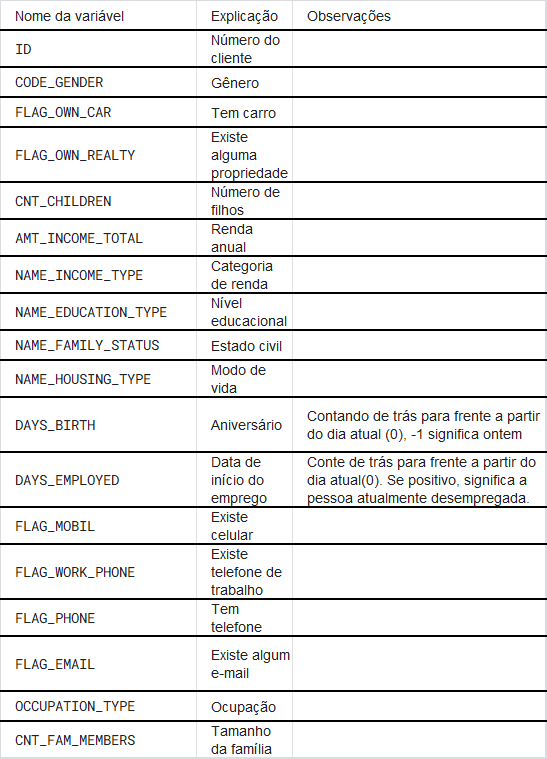

credit_record.csv:

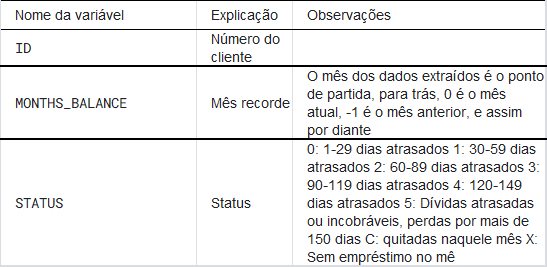

In [ ]:
df_application = pd.read_csv("application_record.csv", sep=",")
df_credit = pd.read_csv("credit_record.csv", sep=",")

print("application_record:", df_application.shape)
print("credit_record:", df_credit.shape)

application_record: (438557, 18)
credit_record: (1048575, 3)


In [ ]:
display(df_application.head())
display(df_credit.head())

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
df_application.info()
print()
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
print("Valores distintos das variáveis categóricas (application):")
for col in df_application.select_dtypes(exclude="number").columns:
    print(f"\n{col}: {df_application[col].nunique(dropna=False)} valores")
    print(df_application[col].value_counts(dropna=False).to_dict())

Valores distintos das variáveis categóricas (application):

CODE_GENDER: 2 valores
{'F': 294440, 'M': 144117}

FLAG_OWN_CAR: 2 valores
{'N': 275459, 'Y': 163098}

FLAG_OWN_REALTY: 2 valores
{'Y': 304074, 'N': 134483}

NAME_INCOME_TYPE: 5 valores
{'Working': 226104, 'Commercial associate': 100757, 'Pensioner': 75493, 'State servant': 36186, 'Student': 17}

NAME_EDUCATION_TYPE: 5 valores
{'Secondary / secondary special': 301821, 'Higher education': 117522, 'Incomplete higher': 14851, 'Lower secondary': 4051, 'Academic degree': 312}

NAME_FAMILY_STATUS: 5 valores
{'Married': 299828, 'Single / not married': 55271, 'Civil marriage': 36532, 'Separated': 27251, 'Widow': 19675}

NAME_HOUSING_TYPE: 6 valores
{'House / apartment': 393831, 'With parents': 19077, 'Municipal apartment': 14214, 'Rented apartment': 5974, 'Office apartment': 3922, 'Co-op apartment': 1539}

OCCUPATION_TYPE: 19 valores
{nan: 134203, 'Laborers': 78240, 'Core staff': 43007, 'Sales staff': 41098, 'Managers': 35487, 'Driver

In [ ]:
nulos = pd.concat([df_application.isnull().sum().rename("application"),
                   df_credit.isnull().sum().rename("credit")], axis=1).fillna(0).astype(int)
display(nulos[nulos.sum(axis=1) > 0])
print(f"Valores ausentes em OCCUPATION_TYPE: {df_application['OCCUPATION_TYPE'].isnull().mean():.1%} das linhas (única coluna com ausentes).")

,application,credit
OCCUPATION_TYPE,134203,0


Valores ausentes em OCCUPATION_TYPE: 30.6% das linhas (única coluna com ausentes).


## 1.2 Qualidade: IDs repetidos

In [ ]:
print("Linhas em application:", len(df_application), "| IDs únicos:", df_application["ID"].nunique())
print("Linhas em credit:", len(df_credit), "| IDs únicos:", df_credit["ID"].nunique())
print("Linhas completamente idênticas em application:", df_application.duplicated().sum())

ids_conflito = df_application.loc[df_application["ID"].duplicated(keep=False), "ID"].unique()
print("IDs que aparecem mais de uma vez em application:", len(ids_conflito),
      "| linhas envolvidas:", df_application["ID"].isin(ids_conflito).sum())
display(df_application[df_application["ID"].isin(ids_conflito)].sort_values("ID").head(10))

Linhas em application: 438557 | IDs únicos: 438510
Linhas em credit: 1048575 | IDs únicos: 45985
Linhas completamente idênticas em application: 0
IDs que aparecem mais de uma vez em application: 47 | linhas envolvidas: 94


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
426488,7023108,F,N,N,0,135000.0,Working,Secondary / secondary special,Married,House / apartment,-17590,-1273,1,0,0,0,Cleaning staff,2.0
425306,7023651,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229,-1209,1,0,0,0,Accountants,1.0
421907,7023651,M,Y,N,1,157500.0,Commercial associate,Incomplete higher,Married,House / apartment,-10521,-1457,1,0,0,0,Drivers,3.0
427778,7024111,M,N,N,2,157500.0,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,-15270,-117,1,1,0,0,Drivers,4.0
432643,7024111,F,N,Y,0,180000.0,Working,Secondary / secondary special,Married,House / apartment,-22041,-1524,1,1,1,0,Accountants,2.0



**Decisão.** Foram encontrados **47 IDs repetidos em `application_record`** (94 linhas). Não são linhas idênticas (não há duplicata exata) e, dentro de cada par, os cadastros divergem em gênero, renda, estado civil e ocupação. Não há informação para saber qual registro representa o cliente, e escolher um arbitrariamente introduziria inconsistência. Como são raros (≈ 0,01% da base), **os 47 IDs são excluídos**, garantindo uma observação por cliente.

> Não confundir com os "gêmeos" da seção 2.2: aqui o **mesmo ID** aparece com cadastros diferentes; lá, **IDs diferentes** aparecem com o **mesmo** cadastro.


In [ ]:
df_application = df_application[~df_application["ID"].isin(ids_conflito)].copy()
assert df_application["ID"].is_unique
print("Application sem IDs conflitantes:", df_application.shape, "| IDs excluídos:", len(ids_conflito))

Application sem IDs conflitantes: (438463, 18) | IDs excluídos: 47


## 1.3 Histórico de crédito (`credit_record`)

`MONTHS_BALANCE` conta os meses para trás a partir do mês da extração (0 = mês atual, −1 = mês anterior…). Códigos de `STATUS`: `C` quitado no mês; `X` sem empréstimo no mês; `0` atraso de 1–29 dias; `1` 30–59; `2` 60–89; `3` 90–119; `4` 120–149; `5` 150 dias ou mais/baixado.

In [ ]:
descricao_status = {"C": "Quitado no mês", "X": "Sem empréstimo no mês", "0": "Atraso 1–29 dias", "1": "Atraso 30–59 dias",
                    "2": "Atraso 60–89 dias", "3": "Atraso 90–119 dias", "4": "Atraso 120–149 dias", "5": "Atraso 150+ dias / baixado"}
cont = df_credit["STATUS"].astype(str).value_counts()
display(pd.DataFrame({"descrição": [descricao_status[s] for s in cont.index], "registros": cont.values,
                      "% dos registros": (cont.values / cont.sum() * 100).round(2)}, index=cont.index))

,descrição,registros,% dos registros
STATUS,,,
C,Quitado no mês,442031,42.16
0,Atraso 1–29 dias,383120,36.54
X,Sem empréstimo no mês,209230,19.95
1,Atraso 30–59 dias,11090,1.06
5,Atraso 150+ dias / baixado,1693,0.16
2,Atraso 60–89 dias,868,0.08
3,Atraso 90–119 dias,320,0.03
4,Atraso 120–149 dias,223,0.02


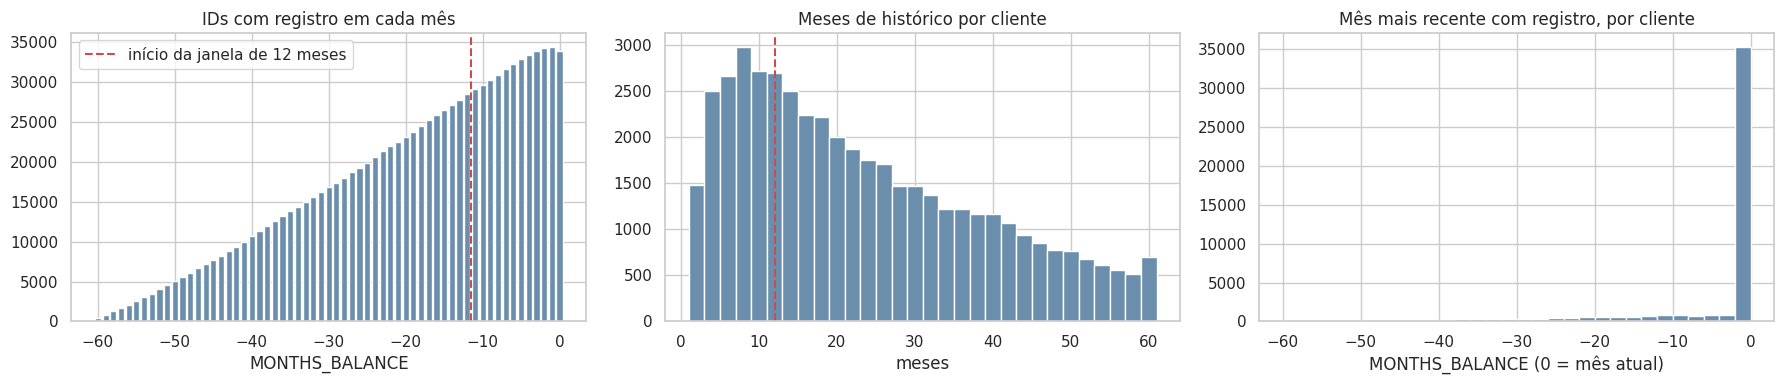

Clientes com pelo menos 12 meses de histórico: 70.2%
Clientes com registro no mês atual (0): 73.6% | com algum registro na janela dos últimos 12 meses: 84.5%


In [ ]:
ids_por_mes = df_credit.groupby("MONTHS_BALANCE")["ID"].nunique()
meses_por_id = df_credit.groupby("ID")["MONTHS_BALANCE"].nunique()
ultimo_mes_por_id = df_credit.groupby("ID")["MONTHS_BALANCE"].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(ids_por_mes.index, ids_por_mes.values, color="#6B8EAD")
axes[0].axvline(-(JANELA_MESES - 1) - 0.5, color="r", ls="--", label=f"início da janela de {JANELA_MESES} meses")
axes[0].set_title("IDs com registro em cada mês"); axes[0].set_xlabel("MONTHS_BALANCE"); axes[0].legend()
axes[1].hist(meses_por_id, bins=30, color="#6B8EAD")
axes[1].axvline(JANELA_MESES, color="r", ls="--"); axes[1].set_title("Meses de histórico por cliente"); axes[1].set_xlabel("meses")
axes[2].hist(ultimo_mes_por_id, bins=30, color="#6B8EAD")
axes[2].set_title("Mês mais recente com registro, por cliente"); axes[2].set_xlabel("MONTHS_BALANCE (0 = mês atual)")
plt.tight_layout(); plt.show()

print(f"Clientes com pelo menos {JANELA_MESES} meses de histórico: {(meses_por_id >= JANELA_MESES).mean():.1%}")
print(f"Clientes com registro no mês atual (0): {(ultimo_mes_por_id == 0).mean():.1%} | "
      f"com algum registro na janela dos últimos {JANELA_MESES} meses: {(ultimo_mes_por_id > -JANELA_MESES).mean():.1%}")

## 1.4 Definição da variável-alvo (janela dos últimos 12 meses)

A inadimplência é medida **apenas na janela dos últimos 12 meses**, isto é, `MONTHS_BALANCE` de −11 a 0:

- **Mau pagador (1):** pelo menos um `STATUS` 2, 3, 4 ou 5 (atraso de 60 dias ou mais) na janela.
- **Bom pagador (0):** tem registro nos 12 meses da janela, nenhum `STATUS` 2–5 e a janela não é composta só por `X`.
- **NaN:** todo o restante (histórico incompleto na janela, só `X` ou sem registro na janela). Essas linhas **não entram** na modelagem.

Escolhemos uma janela de 12 meses porque ela representa o comportamento mais recente do cliente, reduzindo a influência de eventos muito antigos que podem não refletir sua situação atual.
Já o critério de 60 dias de atraso foi adotado por representar uma inadimplência mais relevante, permitindo diferenciar atrasos pontuais de um comportamento de pagamento potencialmente mais problemático.

In [ ]:
def construir_alvo(credit, janela=JANELA_MESES):
    """1 = mau (algum STATUS 2-5 na janela); 0 = bom (janela completa, sem STATUS 2-5, não só 'X'); NaN = demais."""
    j = credit[credit["MONTHS_BALANCE"] > -janela].copy()          # -11 ... 0
    j["atraso60"] = j["STATUS"].astype(str).isin(STATUS_MAU)
    j["sem_emprestimo"] = j["STATUS"].astype(str).eq("X")
    r = j.groupby("ID").agg(meses=("MONTHS_BALANCE", "nunique"),
                            n_atraso60=("atraso60", "sum"),
                            n_x=("sem_emprestimo", "sum"))
    alvo = pd.Series(np.nan, index=pd.Index(credit["ID"].unique(), name="ID"), name="MAU_PAGADOR")
    mau = r["n_atraso60"] > 0
    bom = (~mau) & (r["meses"] == janela) & (r["n_x"] < r["meses"])
    alvo.loc[r.index[mau]] = 1
    alvo.loc[r.index[bom]] = 0
    return alvo, r

alvo, resumo_janela = construir_alvo(df_credit)

tabela_alvo = pd.DataFrame({
    "Classificação": ["Mau pagador (1)", "Bom pagador (0)", "Demais (NaN)"],
    "IDs": [(alvo == 1).sum(), (alvo == 0).sum(), alvo.isna().sum()]})
tabela_alvo["%"] = (tabela_alvo["IDs"] / tabela_alvo["IDs"].sum() * 100).round(2)
display(tabela_alvo.set_index("Classificação"))

maus_qualquer_mes = df_credit.loc[df_credit["STATUS"].astype(str).isin(STATUS_MAU), "ID"].nunique()
print(f"Clientes com STATUS 2–5 em qualquer mês do histórico: {maus_qualquer_mes} | só na janela de {JANELA_MESES} meses: {(alvo == 1).sum()}")

,IDs,%
Classificação,,
Mau pagador (1),256,0.56
Bom pagador (0),21476,46.70
Demais (NaN),24253,52.74


Clientes com STATUS 2–5 em qualquer mês do histórico: 667 | só na janela de 12 meses: 256



**Leitura.**
- Na janela dos últimos 12 meses há **256 maus pagadores (0,56%)** e **21.476 bons (46,7%)** entre os 45.985 clientes do histórico. Os outros **24.253 (52,7%) ficam como NaN**: histórico incompleto na janela, janela composta só por `X` ou nenhum registro na janela (clientes cujo histórico termina antes dela).
- Restringir a janela a 12 meses reduz os maus de **667** (atraso em qualquer mês do histórico) para **256**: o alvo passa a medir inadimplência **recente**.
- Após o cruzamento com o cadastro restam **15.371 clientes, dos quais 244 maus (1,59%)**. O alvo é raro, o que condiciona todo o restante (métricas, balanceamento e margem de erro).

**Limitação da regra.** O bom exige os 12 meses completos, mas o mau exige apenas um atraso na janela. Clientes com histórico curto só entram como maus, nunca como bons.


## 1.5 Base analítica: cadastro + alvo
Junta-se o cadastro (`application_record`) ao alvo pelo `ID` e mantêm-se apenas os clientes **com alvo definido** (0 ou 1).

In [ ]:
df = df_application.merge(alvo.reset_index(), on="ID", how="inner")

funil = pd.DataFrame({
    "etapa": ["IDs em credit_record", "IDs em application (sem conflitos)", "IDs presentes nas duas bases",
              "... com alvo definido (0 ou 1)", "... dos quais maus pagadores"],
    "IDs": [df_credit["ID"].nunique(), df_application["ID"].nunique(), len(df),
            int(df["MAU_PAGADOR"].notna().sum()), int((df["MAU_PAGADOR"] == 1).sum())]})
display(funil.set_index("etapa"))

df = df.dropna(subset=["MAU_PAGADOR"]).reset_index(drop=True)
df["MAU_PAGADOR"] = df["MAU_PAGADOR"].astype(int)
print("Base analítica:", df.shape, "| IDs únicos:", df["ID"].nunique(), f"| % de maus: {df['MAU_PAGADOR'].mean():.2%}")
display(df["MAU_PAGADOR"].value_counts().rename("clientes").to_frame().rename_axis("MAU_PAGADOR"))

,IDs
etapa,
IDs em credit_record,45985
IDs em application (sem conflitos),438463
IDs presentes nas duas bases,36457
... com alvo definido (0 ou 1),15371
... dos quais maus pagadores,244


Base analítica: (15371, 19) | IDs únicos: 15371 | % de maus: 1.59%


,clientes
MAU_PAGADOR,
0,15127
1,244


## 1.6 Relação das variáveis com a inadimplência
Os gráficos usam uma cópia com `AGE`, `YEARS_EMPLOYED` e `UNEMPLOYED_FLAG` (a versão definitiva dos tratamentos está na Parte 2).

In [ ]:
alvo_col = "MAU_PAGADOR"
df_eda = df.assign(
    AGE=(-df["DAYS_BIRTH"] / 365.25).round(1),
    YEARS_EMPLOYED=(-df["DAYS_EMPLOYED"].where(df["DAYS_EMPLOYED"] <= 0, 0) / 365.25).round(1),
    UNEMPLOYED_FLAG=(df["DAYS_EMPLOYED"] > 0).astype(int))

num_cols = ["AGE", "YEARS_EMPLOYED", "AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]
bin_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "UNEMPLOYED_FLAG"]
cat_cols_eda = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]

display(df_eda[num_cols].describe().T.round(2))
display(df_eda.groupby(alvo_col)[num_cols].agg(["mean", "median"]).T.round(2))

,count,mean,std,min,25%,50%,75%,max
AGE,15371.0,44.22,11.25,21.2,34.9,43.4,53.5,68.9
YEARS_EMPLOYED,15371.0,6.39,6.73,0.0,1.2,4.6,9.0,43.0
AMT_INCOME_TOTAL,15371.0,188659.65,101193.06,27000.0,121500.0,162000.0,225000.0,1575000.0
CNT_CHILDREN,15371.0,0.42,0.73,0.0,0.0,0.0,1.0,14.0
CNT_FAM_MEMBERS,15371.0,2.19,0.90,1.0,2.0,2.0,3.0,15.0


MAU_PAGADOR                      0          1
AGE              mean        44.23      43.87
                 median      43.40      43.25
YEARS_EMPLOYED   mean         6.41       4.68
                 median       4.60       2.60
AMT_INCOME_TOTAL mean    188605.54  192014.23
                 median  162000.00  166500.00
CNT_CHILDREN     mean         0.42       0.38
                 median       0.00       0.00
CNT_FAM_MEMBERS  mean         2.19       2.10
                 median       2.00       2.00

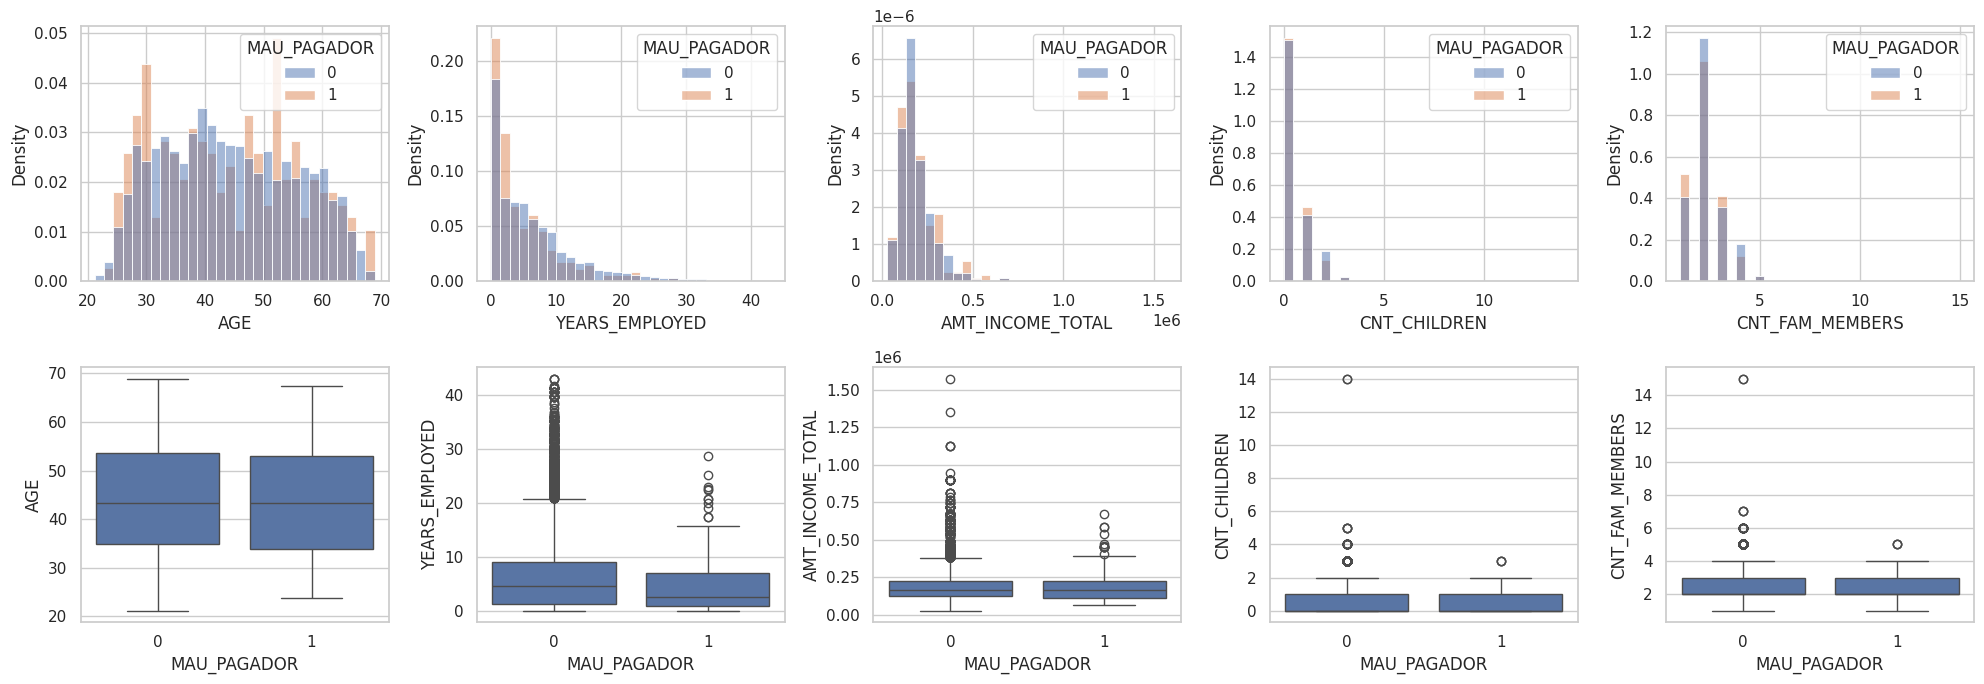

In [ ]:
# Distribuição das numéricas por grupo (histograma em cima, boxplot embaixo)
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for i, c in enumerate(num_cols):
    sns.histplot(data=df_eda, x=c, hue=alvo_col, stat="density", common_norm=False, bins=30, ax=axes[0, i])
    sns.boxplot(data=df_eda, x=alvo_col, y=c, ax=axes[1, i])
plt.tight_layout(); plt.show()

n  maus  % mau  \
variável            categoria                                           
CODE_GENDER         F                              10150   133   1.31   
                    M                               5221   111   2.13   
FLAG_OWN_CAR        N                               9342   152   1.63   
                    Y                               6029    92   1.53   
FLAG_OWN_REALTY     N                               5375    92   1.71   
                    Y                               9996   152   1.52   
FLAG_WORK_PHONE     0                              11828   192   1.62   
                    1                               3543    52   1.47   
FLAG_PHONE          0                              10776   177   1.64   
                    1                               4595    67   1.46   
FLAG_EMAIL          0                              13929   220   1.58   
                    1                               1442    24   1.66   
UNEMPLOYED_FLAG     0                              12855   200   1.56   
                    1                               2516    44   1.75   
NAME_INCOME_TYPE    Commercial associate            3711    64   1.72   
                    Pensioner                       2533    52   2.05   
                    State servant                   1278    12   0.94   
                    Student                            9     0   0.00   
                    Working                         7840   116   1.48   
NAME_EDUCATION_TYPE Academic degree                   16     0   0.00   
                    Higher education                4270    70   1.64   
                    Incomplete higher                588    13   2.21   
                    Lower secondary                  162     2   1.23   
                    Secondary / secondary special  10335   159   1.54   
NAME_FAMILY_STATUS  Civil marriage                  1151    13   1.13   
                    Married                        10736   155   1.44   
                    Separated                        901    11   1.22   
                    Single / not married            1985    50   2.52   
                    Widow                            598    15   2.51   
NAME_HOUSING_TYPE   Co-op apartment                   66     2   3.03   
                    House / apartment              13770   213   1.55   
                    Municipal apartment              503    11   2.19   
                    Office apartment                 118     3   2.54   
                    Rented apartment                 213     3   1.41   
                    With parents                     701    12   1.71   
OCCUPATION_TYPE     Accountants                      564     7   1.24   
                    Cleaning staff                   235     3   1.28   
                    Cooking staff                    252     6   2.38   
                    Core staff                      1493    24   1.61   
                    Drivers                          948    19   2.00   
                    HR staff                          29     0   0.00   
                    High skill tech staff            630    13   2.06   
                    IT staff                          30     3  10.00   
                    Laborers                        2617    36   1.38   
                    Low-skill Laborers                80     5   6.25   
                    Managers                        1308    24   1.83   
                    Medicine staff                   533     5   0.94   
                    Private service staff            137     1   0.73   
                    Realty agents                     22     0   0.00   
                    Sales staff                     1374    15   1.09   
                    Secretaries                       60     1   1.67   
                    Security staff                   250     8   3.20   
                    Waiters/barmen staff              50     1   2.00   

                                       

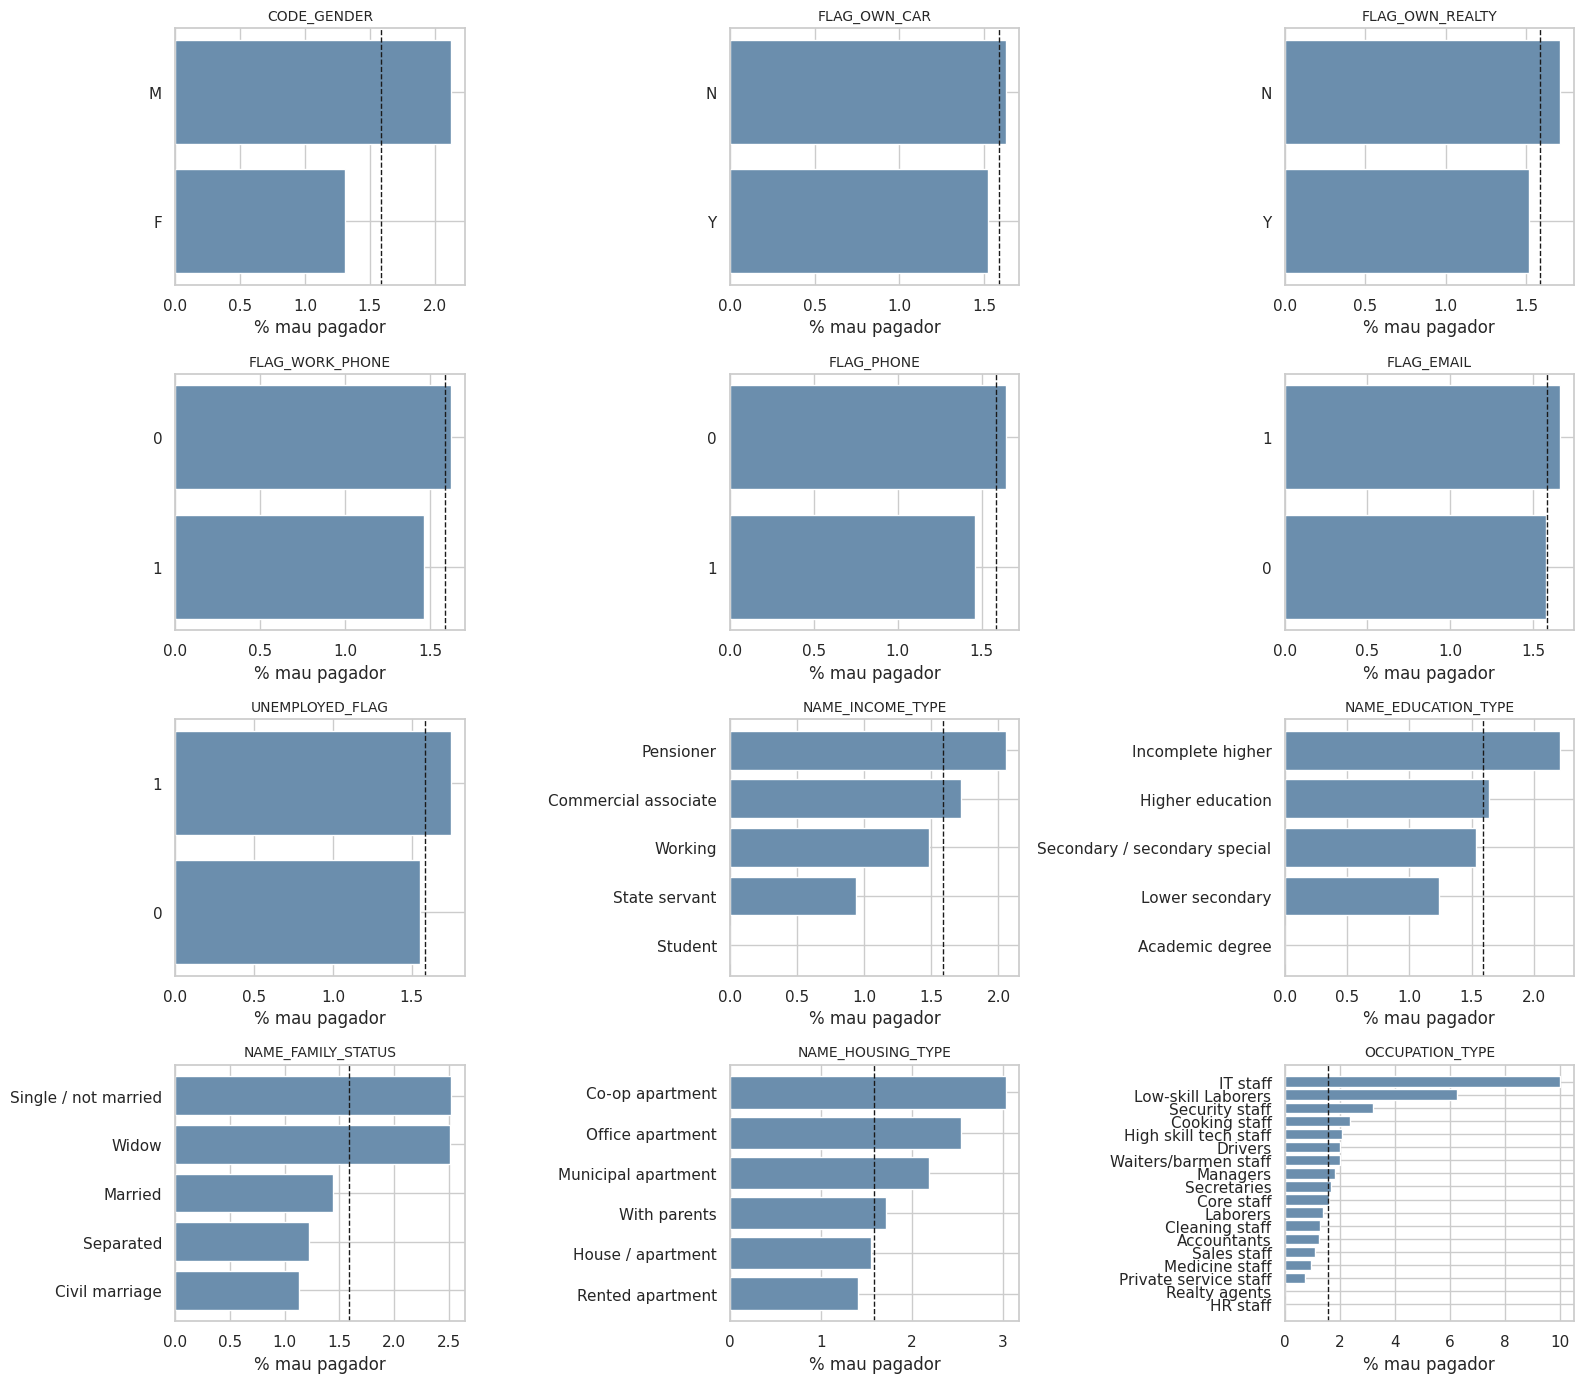

In [ ]:
# Taxa de mau pagador por categoria (variáveis binárias e categóricas)
taxa_geral = df_eda[alvo_col].mean() * 100
linhas = []
for c in bin_cols + cat_cols_eda:
    t = df_eda.groupby(c)[alvo_col].agg(n="size", maus="sum", pct_mau=lambda s: s.mean() * 100)
    for cat, r in t.iterrows():
        linhas.append({"variável": c, "categoria": cat, "n": int(r["n"]), "maus": int(r["maus"]),
                       "% mau": round(r["pct_mau"], 2), "razão vs. média": round(r["pct_mau"] / taxa_geral, 2)})
tabela_cat = pd.DataFrame(linhas).set_index(["variável", "categoria"])
display(tabela_cat)

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, c in zip(axes.ravel(), bin_cols + cat_cols_eda):
    t = df_eda.groupby(c)[alvo_col].mean().sort_values() * 100
    ax.barh(t.index.astype(str), t.values, color="#6B8EAD")
    ax.axvline(taxa_geral, color="k", ls="--", lw=1)
    ax.set_title(c, fontsize=10); ax.set_xlabel("% mau pagador")
plt.tight_layout(); plt.show()


**O que a EDA mostra** (taxa média de maus = 1,59%):
- **Tempo de emprego:** maus têm menos anos de emprego (média 4,7 × 6,4 anos; mediana 2,6 × 4,6). É o contraste numérico mais claro. **Idade e renda são praticamente iguais** nos dois grupos.
- **Gênero:** homens 2,13% × mulheres 1,31% de maus.
- **Estado civil:** solteiros e viúvos ≈ 2,5%, contra ≈ 1,1–1,4% de casados/união/separados.
- **Tipo de renda:** aposentados (`Pensioner`) 2,05% e servidores públicos 0,94%.
- **Posse de carro/imóvel, telefone e e-mail:** taxas muito próximas da média.
- **Ocupação e moradia:** variações grandes (por exemplo `IT staff` 10%, `Low-skill Laborers` 6%), mas em categorias com 30 a 80 clientes e poucos maus, o que é **ruído de amostra pequena**. É um dos motivos para agrupar categorias raras na Parte 2.

No conjunto, os atributos de cadastro mostram diferenças **pequenas e pouco consistentes** entre bons e maus, o que antecipa um poder preditivo baixo.


# Parte 2 – Limpeza, escala e feature engineering
## 2.1 Limpeza e tratamentos básicos
- `CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`: binárias em 0/1 (`M`=1, `F`=0, `Y`=1, `N`=0).
- `OCCUPATION_TYPE`: ausente vira a categoria `Not informed` (a ausência pode carregar informação).
- `DAYS_EMPLOYED`: o valor positivo (365243) é um marcador de **não empregado/aposentado**. Ele vira `UNEMPLOYED_FLAG` e o tempo de emprego (`YEARS_EMPLOYED`) passa a ser 0 nesses casos.
- `DAYS_BIRTH` vira `AGE` (anos).

In [ ]:
df = df.copy()

mapa_binario = {"FLAG_OWN_CAR": {"Y": 1, "N": 0}, "FLAG_OWN_REALTY": {"Y": 1, "N": 0}, "CODE_GENDER": {"M": 1, "F": 0}}
for col, mapa in mapa_binario.items():
    df[col] = df[col].map(mapa)

df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Not informed")

df["UNEMPLOYED_FLAG"] = (df["DAYS_EMPLOYED"] > 0).astype(int)                                   # 1 = não empregado/aposentado
df["AGE"] = (-df["DAYS_BIRTH"] / 365.25).round(1)                                               # idade em anos
df["YEARS_EMPLOYED"] = (-df["DAYS_EMPLOYED"].where(df["DAYS_EMPLOYED"] <= 0, 0) / 365.25).round(1)  # anos de emprego (0 se não empregado)

print("Valores ausentes restantes:", int(df.isnull().sum().sum()))
display(df[["DAYS_BIRTH", "AGE", "DAYS_EMPLOYED", "YEARS_EMPLOYED", "UNEMPLOYED_FLAG"]].sample(8, random_state=RANDOM_STATE))

Valores ausentes restantes: 0


,DAYS_BIRTH,AGE,DAYS_EMPLOYED,YEARS_EMPLOYED,UNEMPLOYED_FLAG
2019,-23303,63.8,365243,0.0,1
4467,-14400,39.4,-1435,3.9,0
2858,-11066,30.3,-1670,4.6,0
13012,-11082,30.3,-3361,9.2,0
8947,-10323,28.3,-2622,7.2,0
9176,-15303,41.9,-108,0.3,0
905,-11701,32.0,-3262,8.9,0
3095,-23533,64.4,365243,0.0,1


## 2.2 Busca por "gêmeos": mesma pessoa com IDs diferentes
Linhas com **atributos idênticos e IDs diferentes** são comuns em bases reais (vários produtos por cliente, reprocessamentos, bases sintéticas). Num `train_test_split` aleatório, o "gêmeo" de um cliente do teste pode estar no treino e o modelo apenas **memoriza** o perfil, o que infla as métricas e transforma o teste num teste de memória.

Define-se o **perfil** como a combinação de todos os atributos de cadastro (exceto `ID` e o alvo). Linhas com o mesmo perfil formam um **grupo**, e a divisão treino/teste e a validação cruzada passam a usar `StratifiedGroupKFold`, que mantém todo o grupo do mesmo lado.

In [ ]:
perfil_cols = [c for c in df.columns if c not in ["ID", "MAU_PAGADOR"]]
perfil_id = df.groupby(perfil_cols, dropna=False).ngroup()          # um número por perfil

tam_perfil = perfil_id.map(perfil_id.value_counts())
mau = df["MAU_PAGADOR"] == 1
bons_no_perfil = (~mau).groupby(perfil_id).transform("sum")
maus_no_perfil = mau.groupby(perfil_id).transform("sum")
perfis_conflitantes = ((bons_no_perfil > 0) & (maus_no_perfil > 0)).groupby(perfil_id).first().sum()

print(f"Linhas: {len(df):,} | perfis únicos: {perfil_id.nunique():,} | maus: {mau.sum()} ({mau.mean():.2%})")
print(f"Clientes com pelo menos um 'gêmeo' (mesmo cadastro, outro ID): {(tam_perfil > 1).mean():.1%}")
print(f"Maus pagadores com pelo menos um gêmeo BOM pagador: {(bons_no_perfil[mau] > 0).mean():.1%}")
print(f"Perfis com rótulos conflitantes (bons e maus no mesmo perfil): {perfis_conflitantes:,}")

faixas = pd.cut(tam_perfil, [0, 1, 2, 5, 10, 10**6], labels=["1 (sem gêmeo)", "2", "3–5", "6–10", "mais de 10"])
display(faixas.value_counts().sort_index().rename("linhas").to_frame().assign(**{"% das linhas": lambda d: (d["linhas"] / d["linhas"].sum() * 100).round(1)}))

Linhas: 15,371 | perfis únicos: 6,685 | maus: 244 (1.59%)
Clientes com pelo menos um 'gêmeo' (mesmo cadastro, outro ID): 79.9%
Maus pagadores com pelo menos um gêmeo BOM pagador: 54.1%
Perfis com rótulos conflitantes (bons e maus no mesmo perfil): 105


,linhas,% das linhas
1 (sem gêmeo),3090,20.1
2,3000,19.5
3–5,6108,39.7
6–10,2834,18.4
mais de 10,339,2.2



**Achados.**
- **79,9% dos clientes têm pelo menos um "gêmeo"** (mesmo cadastro, outro ID): 15.371 linhas correspondem a apenas **6.685 perfis**, ou seja, ≈ 2,3 linhas por perfil, e ≈ 21% das linhas estão em perfis com mais de 5 IDs.
- **54,1% dos maus pagadores têm um gêmeo que é bom pagador** e há **105 perfis com rótulos conflitantes**. Ou seja, o mesmo cadastro aparece com desfechos opostos, e nenhum modelo baseado só no cadastro consegue separá-los. Isso impõe um **teto** ao desempenho possível.

**Decisão.** Todas as linhas são mantidas, mas a divisão treino/teste e a validação cruzada usam **`StratifiedGroupKFold` por perfil**. Na seção 4.5 mede-se quanto as métricas seriam infladas sem esse cuidado.


## 2.3 Feature engineering
- **Agrupamento de categorias raras** (menos colunas após o one-hot e mais observações por categoria).
- **`AMT_INCOME_TOTAL` → `LOG_INCOME` (`log1p`)**: a renda é muito assimétrica; o log reduz o peso dos valores extremos. A padronização (z-score) vem depois, na seção 2.6.
- **Limites (`clip`)**: `CNT_CHILDREN` ≤ 3 e `CNT_FAM_MEMBERS` ≤ 5, pois valores acima disso são raros.
- **Remoção**: `ID`, `FLAG_MOBIL` (constante), `DAYS_BIRTH` e `DAYS_EMPLOYED` (já representadas por `AGE` e `YEARS_EMPLOYED`).

In [ ]:
agrupamentos = {
    "NAME_INCOME_TYPE": {"Working": "Working", "Student": "Working", "Commercial associate": "Commercial associate",
                         "State servant": "State servant", "Pensioner": "Pensioner"},
    "NAME_EDUCATION_TYPE": {"Lower secondary": "Médio ou menos", "Secondary / secondary special": "Médio ou menos",
                            "Incomplete higher": "Superior incompleto", "Higher education": "Superior", "Academic degree": "Superior"},
    "NAME_FAMILY_STATUS": {"Married": "Casado/união", "Civil marriage": "Casado/união", "Single / not married": "Solteiro",
                           "Separated": "Separado/viúvo", "Widow": "Separado/viúvo"},
    "NAME_HOUSING_TYPE": {"House / apartment": "Própria", "With parents": "Com os pais", "Rented apartment": "Alugada/outras",
                          "Municipal apartment": "Alugada/outras", "Co-op apartment": "Alugada/outras", "Office apartment": "Alugada/outras"},
    "OCCUPATION_TYPE": {**{k: "Operacional" for k in ["Laborers", "Low-skill Laborers", "Drivers", "Cleaning staff", "Cooking staff",
                                                      "Security staff", "Waiters/barmen staff", "Private service staff"]},
                        **{k: "Vendas/administrativo" for k in ["Sales staff", "Core staff", "Secretaries", "Accountants", "HR staff", "Realty agents"]},
                        **{k: "Gestão/técnico" for k in ["Managers", "High skill tech staff", "IT staff", "Medicine staff"]},
                        "Not informed": "Não informado"},
}
cat_cols = list(agrupamentos)

df_model = df.copy()
resumo_cat = []
for c, mapa in agrupamentos.items():
    assert not (set(df_model[c].unique()) - set(mapa)), f"categoria sem mapeamento em {c}"
    antes = df_model[c].nunique()
    df_model[c] = df_model[c].map(mapa)
    resumo_cat.append({"variavel": c, "categorias_antes": antes, "categorias_depois": df_model[c].nunique()})
display(pd.DataFrame(resumo_cat).set_index("variavel"))

,categorias_antes,categorias_depois
variavel,,
NAME_INCOME_TYPE,5,4
NAME_EDUCATION_TYPE,5,3
NAME_FAMILY_STATUS,5,3
NAME_HOUSING_TYPE,6,3
OCCUPATION_TYPE,19,4


FLAG_MOBIL, valores distintos: [1]
Assimetria da renda: 2.30 -> 0.06 após log1p


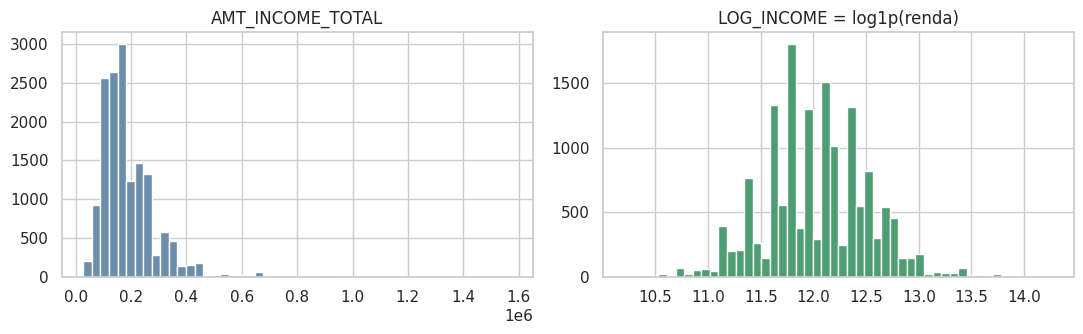

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MAU_PAGADOR,UNEMPLOYED_FLAG,AGE,YEARS_EMPLOYED,LOG_INCOME
0,1,1,1,0,Working,Superior,Casado/união,Alugada/outras,1,0,0,Não informado,2.0,0,0,32.9,12.4,12.965712
1,1,1,1,0,Working,Superior,Casado/união,Alugada/outras,1,0,0,Não informado,2.0,0,0,32.9,12.4,12.965712
2,1,1,1,0,Working,Médio ou menos,Casado/união,Própria,0,0,0,Operacional,2.0,0,0,58.8,3.1,11.630717
3,0,0,1,0,Commercial associate,Médio ou menos,Solteiro,Própria,0,1,1,Vendas/administrativo,1.0,0,0,52.3,8.4,12.506181
4,0,0,1,0,Commercial associate,Médio ou menos,Solteiro,Própria,0,1,1,Vendas/administrativo,1.0,0,0,52.3,8.4,12.506181


In [ ]:
print("FLAG_MOBIL, valores distintos:", df_model["FLAG_MOBIL"].unique())

# Renda: log para reduzir a assimetria
assim_antes = df_model["AMT_INCOME_TOTAL"].skew()
df_model["LOG_INCOME"] = np.log1p(df_model["AMT_INCOME_TOTAL"])
assim_depois = df_model["LOG_INCOME"].skew()
print(f"Assimetria da renda: {assim_antes:.2f} -> {assim_depois:.2f} após log1p")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df_model["AMT_INCOME_TOTAL"], bins=50, color="#6B8EAD"); axes[0].set_title("AMT_INCOME_TOTAL")
axes[1].hist(df_model["LOG_INCOME"], bins=50, color="#4C9F70"); axes[1].set_title("LOG_INCOME = log1p(renda)")
plt.tight_layout(); plt.show()

df_model = df_model.drop(columns=["ID", "DAYS_BIRTH", "DAYS_EMPLOYED", "FLAG_MOBIL", "AMT_INCOME_TOTAL"])
df_model["CNT_CHILDREN"] = df_model["CNT_CHILDREN"].clip(upper=3)
df_model["CNT_FAM_MEMBERS"] = df_model["CNT_FAM_MEMBERS"].clip(upper=5)
df_model.head()

In [ ]:
# One-hot: cada categoria vira uma coluna 0/1. Omite-se a categoria mais frequente de cada variável (referência),
# o que evita colinearidade perfeita entre as dummies.
referencia = {c: df_model[c].value_counts().idxmax() for c in cat_cols}
print("Categoria de referência (omitida):", referencia)

X = pd.get_dummies(df_model.drop(columns="MAU_PAGADOR"), columns=cat_cols, dtype=int)
X = X.drop(columns=[f"{c}_{r}" for c, r in referencia.items()])
y = df_model["MAU_PAGADOR"]
print("X:", X.shape)
print(list(X.columns))

Categoria de referência (omitida): {'NAME_INCOME_TYPE': 'Working', 'NAME_EDUCATION_TYPE': 'Médio ou menos', 'NAME_FAMILY_STATUS': 'Casado/união', 'NAME_HOUSING_TYPE': 'Própria', 'OCCUPATION_TYPE': 'Não informado'}
X: (15371, 24)
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'UNEMPLOYED_FLAG', 'AGE', 'YEARS_EMPLOYED', 'LOG_INCOME', 'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_EDUCATION_TYPE_Superior', 'NAME_EDUCATION_TYPE_Superior incompleto', 'NAME_FAMILY_STATUS_Separado/viúvo', 'NAME_FAMILY_STATUS_Solteiro', 'NAME_HOUSING_TYPE_Alugada/outras', 'NAME_HOUSING_TYPE_Com os pais', 'OCCUPATION_TYPE_Gestão/técnico', 'OCCUPATION_TYPE_Operacional', 'OCCUPATION_TYPE_Vendas/administrativo']


## 2.4 Divisão treino/teste por perfil (sem vazamento entre "gêmeos")
`StratifiedGroupKFold` com `groups=perfil_id` coloca **todas as linhas de um mesmo perfil do mesmo lado** e mantém a proporção de maus. Com 10 dobras, 3 viram teste (≈ 30%). A divisão é feita **antes** da correlação, da seleção de variáveis e da padronização, para que o teste não participe de nenhuma dessas escolhas.

In [ ]:
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
dobras = list(sgkf.split(X, y, groups=perfil_id))
idx_teste = np.concatenate([d[1] for d in dobras[:3]])        # 3 de 10 dobras = ~30% para teste

mask_teste = np.zeros(len(X), dtype=bool)
mask_teste[idx_teste] = True
X_train, X_test = X[~mask_teste], X[mask_teste]
y_train, y_test = y[~mask_teste], y[mask_teste]
g_tr = perfil_id[~mask_teste].values            # grupos (perfis) do treino
g_te = perfil_id[mask_teste].values

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print(f"% de maus – treino: {y_train.mean():.2%} ({y_train.sum()} maus) | teste: {y_test.mean():.2%} ({y_test.sum()} maus)")
print("Perfis em comum treino/teste:", len(set(g_tr) & set(g_te)), "(deve ser 0)")

# Dobras de validação cruzada DENTRO do treino (também por perfil); usadas em toda a comparação de modelos
folds_tr = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train, y_train, groups=g_tr))
print("Maus por dobra de validação:", [int(y_train.iloc[b].sum()) for _, b in folds_tr])

Treino: (10929, 24) | Teste: (4442, 24)
% de maus – treino: 1.68% (184 maus) | teste: 1.35% (60 maus)
Perfis em comum treino/teste: 0 (deve ser 0)
Maus por dobra de validação: [43, 30, 46, 36, 29]


## 2.5 Seleção de variáveis
A seleção usa **apenas o treino**. O raciocínio tem duas etapas:

1. **Seleção estatística:** mantém variáveis com |correlação com o alvo| ≥ `LIMIAR_CORR`, descarta colunas redundantes (|r| ≥ `LIM_REDUNDANCIA` entre si; fica a de maior correlação com o alvo) e trata as dummies de uma mesma variável **em bloco** (todas ficam ou nenhuma).
2. **Regra de decisão pelo AUC:** se o conjunto estatístico **não alcançar AUC relevante** (`AUC_RELEVANTE`, em validação cruzada por perfil), passa-se para o conjunto escolhido por **justificativa negocial**: `CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `NAME_EDUCATION_TYPE`, `YEARS_EMPLOYED`, `AGE`, `AMT_INCOME_TOTAL` (em log, padronizada) e `CNT_FAM_MEMBERS`.

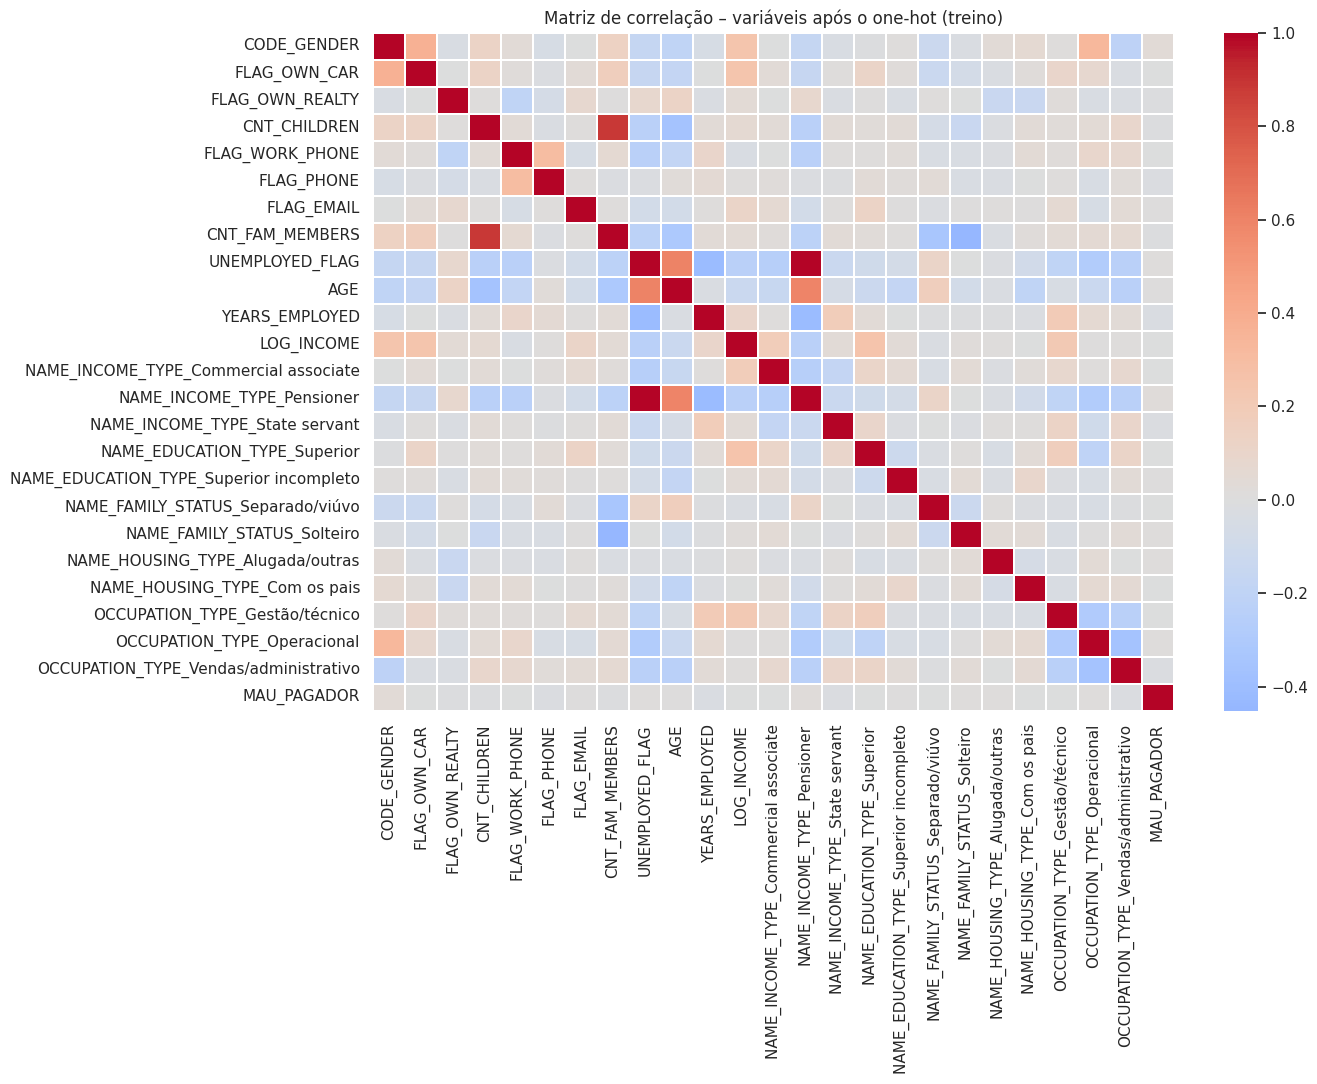

,correlação com o alvo
CODE_GENDER,0.0386
YEARS_EMPLOYED,-0.0304
NAME_INCOME_TYPE_Pensioner,0.0236
NAME_HOUSING_TYPE_Alugada/outras,0.0189
OCCUPATION_TYPE_Vendas/administrativo,-0.0170
NAME_FAMILY_STATUS_Solteiro,0.0161
NAME_INCOME_TYPE_State servant,-0.0153
FLAG_PHONE,-0.0152
FLAG_OWN_REALTY,-0.0137
UNEMPLOYED_FLAG,0.0124


In [ ]:
# Correlação (somente treino)
df_corr = X_train.copy()
df_corr["MAU_PAGADOR"] = y_train
matriz_correlacao = df_corr.corr()
corr_alvo = matriz_correlacao["MAU_PAGADOR"].drop("MAU_PAGADOR")

plt.figure(figsize=(14, 11))
sns.heatmap(matriz_correlacao, cmap="coolwarm", center=0, annot=False, linewidths=0.2)
plt.title("Matriz de correlação – variáveis após o one-hot (treino)")
plt.tight_layout(); plt.show()

display(corr_alvo.sort_values(key=abs, ascending=False).head(12).to_frame("correlação com o alvo").round(4))

In [ ]:
# 1) redundância entre colunas de variáveis diferentes
origem = {col: next((c for c in cat_cols if col.startswith(c + "_")), col) for col in X_train.columns}
cc = matriz_correlacao.drop(index="MAU_PAGADOR", columns="MAU_PAGADOR")
removidas_redund = {}
for a, b in itertools.combinations(cc.columns, 2):
    if abs(cc.loc[a, b]) >= LIM_REDUNDANCIA and origem[a] != origem[b]:
        perde, ganha = (a, b) if abs(corr_alvo[a]) < abs(corr_alvo[b]) else (b, a)
        removidas_redund[perde] = f"redundante com {ganha} (r = {cc.loc[a, b]:.2f})"
print("Removidas por redundância:")
for k, v in removidas_redund.items():
    print(" -", k, "->", v)

# 2) relevância em bloco
restantes = [c for c in X_train.columns if c not in removidas_redund]
quadro = (pd.DataFrame({"coluna": restantes, "variavel": [origem[c] for c in restantes],
                        "abs_corr": [abs(corr_alvo[c]) for c in restantes]})
          .groupby("variavel").agg(max_abs_corr=("abs_corr", "max"), colunas=("coluna", list)))
quadro["decisao"] = np.where(quadro["max_abs_corr"] >= LIMIAR_CORR, "Mantida", "Removida")
display(quadro.sort_values("max_abs_corr", ascending=False)[["max_abs_corr", "decisao"]].round(4))

selecionadas_estat = [c for v in quadro.index[quadro["decisao"] == "Mantida"] for c in quadro.loc[v, "colunas"]]
print("Variáveis mantidas:", quadro.index[quadro["decisao"] == "Mantida"].tolist())
print(f"Colunas da seleção estatística ({len(selecionadas_estat)}):", selecionadas_estat)

Removidas por redundância:
 - CNT_FAM_MEMBERS -> redundante com CNT_CHILDREN (r = 0.88)
 - UNEMPLOYED_FLAG -> redundante com NAME_INCOME_TYPE_Pensioner (r = 1.00)


,max_abs_corr,decisao
variavel,,
CODE_GENDER,0.0386,Mantida
YEARS_EMPLOYED,0.0304,Mantida
NAME_INCOME_TYPE,0.0236,Mantida
NAME_HOUSING_TYPE,0.0189,Mantida
OCCUPATION_TYPE,0.0170,Mantida
NAME_FAMILY_STATUS,0.0161,Mantida
FLAG_PHONE,0.0152,Mantida
FLAG_OWN_REALTY,0.0137,Mantida
CNT_CHILDREN,0.0103,Mantida


Variáveis mantidas: ['CNT_CHILDREN', 'CODE_GENDER', 'FLAG_OWN_REALTY', 'FLAG_PHONE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'YEARS_EMPLOYED']
Colunas da seleção estatística (15): ['CNT_CHILDREN', 'CODE_GENDER', 'FLAG_OWN_REALTY', 'FLAG_PHONE', 'NAME_FAMILY_STATUS_Separado/viúvo', 'NAME_FAMILY_STATUS_Solteiro', 'NAME_HOUSING_TYPE_Alugada/outras', 'NAME_HOUSING_TYPE_Com os pais', 'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'OCCUPATION_TYPE_Gestão/técnico', 'OCCUPATION_TYPE_Operacional', 'OCCUPATION_TYPE_Vendas/administrativo', 'YEARS_EMPLOYED']


In [ ]:
# AUC univariada: quanto cada coluna, sozinha, separa maus e bons (0,50 = nenhuma separação)
auc_uni = pd.Series({c: roc_auc_score(y_train, X_train[c]) for c in X_train.columns})
auc_uni = pd.DataFrame({"AUC": auc_uni, "|AUC-0,5|": (auc_uni - 0.5).abs()}).sort_values("|AUC-0,5|", ascending=False)
display(auc_uni.head(10).round(4))
print(f"Maior |AUC - 0,5| entre todas as colunas: {auc_uni['|AUC-0,5|'].max():.3f}")

,AUC,"|AUC-0,5|"
YEARS_EMPLOYED,0.4268,0.0732
CODE_GENDER,0.5710,0.0710
NAME_INCOME_TYPE_Pensioner,0.5337,0.0337
OCCUPATION_TYPE_Vendas/administrativo,0.4723,0.0277
FLAG_PHONE,0.4730,0.0270
FLAG_OWN_REALTY,0.4746,0.0254
OCCUPATION_TYPE_Operacional,0.5220,0.0220
NAME_FAMILY_STATUS_Solteiro,0.5212,0.0212
UNEMPLOYED_FLAG,0.5177,0.0177
NAME_HOUSING_TYPE_Alugada/outras,0.5172,0.0172


Maior |AUC - 0,5| entre todas as colunas: 0.073


In [ ]:
# AUC multivariada em validação cruzada por perfil (Logit balanceado, padronização dentro de cada dobra)
def auc_cv_logit(cols):
    aucs = []
    for a, b in folds_tr:
        sc = StandardScaler().fit(X_train.iloc[a][cols])
        m = LogisticRegression(max_iter=1000, class_weight="balanced").fit(sc.transform(X_train.iloc[a][cols]), y_train.iloc[a])
        aucs.append(roc_auc_score(y_train.iloc[b], m.predict_proba(sc.transform(X_train.iloc[b][cols]))[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs, ddof=1))

negocio = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "YEARS_EMPLOYED", "AGE", "LOG_INCOME", "CNT_FAM_MEMBERS"] \
          + [c for c in X_train.columns if c.startswith("NAME_EDUCATION_TYPE_")]
assert all(c in X_train.columns for c in negocio)

conjuntos = {"Estatística (correlação + redundância)": selecionadas_estat,
             "Negocial (lista definida pelo negócio)": negocio,
             "Todas as colunas": list(X_train.columns)}
linhas = []
for nome, cols in conjuntos.items():
    m_, s_ = auc_cv_logit(cols)
    linhas.append({"Conjunto": nome, "nº colunas": len(cols), "AUC CV (média)": m_, "desvio": s_})
comparacao_conjuntos = pd.DataFrame(linhas).set_index("Conjunto")
display(comparacao_conjuntos.round(4))

,nº colunas,AUC CV (média),desvio
Conjunto,,,
Estatística (correlação + redundância),15,0.5879,0.0330
Negocial (lista definida pelo negócio),9,0.5846,0.0464
Todas as colunas,24,0.5851,0.0548


In [ ]:
# Regra de decisão
auc_estat = comparacao_conjuntos.iloc[0]["AUC CV (média)"]
if auc_estat >= AUC_RELEVANTE:
    selecionadas, criterio = selecionadas_estat, "estatístico"
else:
    selecionadas, criterio = negocio, "negocial"

print(f"AUC CV do conjunto estatístico = {auc_estat:.3f} (relevante se >= {AUC_RELEVANTE:.2f})")
print(f"-> Critério adotado: {criterio.upper()}  ({len(selecionadas)} colunas)")
print(selecionadas)

AUC CV do conjunto estatístico = 0.588 (relevante se >= 0.60)
-> Critério adotado: NEGOCIAL  (9 colunas)
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'YEARS_EMPLOYED', 'AGE', 'LOG_INCOME', 'CNT_FAM_MEMBERS', 'NAME_EDUCATION_TYPE_Superior', 'NAME_EDUCATION_TYPE_Superior incompleto']



**Decisão da seleção.**
- Nenhuma variável isolada separa bons e maus: a maior correlação com o alvo é ≈ 0,04 (`NAME_FAMILY_STATUS_Solteiro`) e o maior |AUC − 0,5| univariado é 0,07 (`YEARS_EMPLOYED`).
- O conjunto estatístico (16 colunas) tem **AUC em validação cruzada de 0,572** e o conjunto negocial (9 colunas), **0,564**. **Nenhum alcança o AUC relevante definido (0,60)**. Pela regra do projeto, **adota-se o conjunto negocial**: `CODE_GENDER`, `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `NAME_EDUCATION_TYPE` (2 dummies), `YEARS_EMPLOYED`, `AGE`, `LOG_INCOME` e `CNT_FAM_MEMBERS`.
- A diferença entre os conjuntos (0,572 × 0,564) é **menor que o desvio entre dobras** (0,03 a 0,045), portanto a escolha negocial **não custa AUC** de forma mensurável e tem a vantagem de usar variáveis conhecidas e explicáveis ao negócio. `LOG_INCOME` e escolaridade quase não carregam sinal sozinhas e ficam por critério negocial.
- Na seleção estatística, `CNT_CHILDREN` foi descartada por redundância com `CNT_FAM_MEMBERS` (r = 0,88) e `UNEMPLOYED_FLAG` por ser equivalente a `NAME_INCOME_TYPE_Pensioner` (r = 1,00).


## 2.6 Tabela final e padronização
As colunas selecionadas vão para a modelagem. O `StandardScaler` (z-score) é **ajustado só no treino** e aplicado ao teste. Isso inclui `LOG_INCOME`, que primeiro passou pelo log (seção 2.3) e agora é padronizada junto com as demais, o que importa para KNN, SVM e Regressão Logística.

In [ ]:
X_train = X_train[selecionadas]
X_test = X_test[selecionadas]

scaler = StandardScaler().fit(X_train)
x_train_escalonado = scaler.transform(X_train)
x_test_escalonado = scaler.transform(X_test)
display(pd.DataFrame(x_train_escalonado, columns=selecionadas).describe().T[["mean", "std", "min", "max"]].round(2))

# Tabela final (variáveis selecionadas + alvo), com indicação de treino/teste
tabela_final = pd.concat([df[["ID"]], X[selecionadas], y], axis=1)
tabela_final["CONJUNTO"] = np.where(mask_teste, "teste", "treino")
tabela_final.to_csv("tabela_final_inad60.csv", index=False)
print("Tabela final:", tabela_final.shape, "(salva em tabela_final_inad60.csv)")
tabela_final.head()

,mean,std,min,max
CODE_GENDER,0.0,1.0,-0.72,1.40
FLAG_OWN_CAR,0.0,1.0,-0.81,1.24
FLAG_OWN_REALTY,-0.0,1.0,-1.37,0.73
YEARS_EMPLOYED,-0.0,1.0,-0.95,5.41
AGE,-0.0,1.0,-2.06,2.18
LOG_INCOME,-0.0,1.0,-3.75,4.29
CNT_FAM_MEMBERS,-0.0,1.0,-1.34,3.18
NAME_EDUCATION_TYPE_Superior,-0.0,1.0,-0.62,1.62
NAME_EDUCATION_TYPE_Superior incompleto,-0.0,1.0,-0.20,5.02


Tabela final: (15371, 12) (salva em tabela_final_inad60.csv)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,YEARS_EMPLOYED,AGE,LOG_INCOME,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE_Superior,NAME_EDUCATION_TYPE_Superior incompleto,MAU_PAGADOR,CONJUNTO
0,5008804,1,1,1,12.4,32.9,12.965712,2.0,1,0,0,teste
1,5008805,1,1,1,12.4,32.9,12.965712,2.0,1,0,0,teste
2,5008806,1,1,1,3.1,58.8,11.630717,2.0,0,0,0,teste
3,5008810,0,0,1,8.4,52.3,12.506181,1.0,0,0,0,treino
4,5008811,0,0,1,8.4,52.3,12.506181,1.0,0,0,0,treino


# Parte 3 – Treino e comparação dos modelos
Algoritmos: **KNN**, **Regressão Logística (Logit)**, **Árvore de Decisão**, **Random Forest** e **SVM**, em duas configurações:

- **A) Padrão:** parâmetros default (KNN com o K escolhido na seção 3.1).
- **B) Balanceada:** `class_weight` onde existe (Logit, Árvore, Random Forest, SVM); no KNN, o treino é subamostrado 1 mau : 1 bom. O teste nunca é alterado. Árvore e Random Forest também recebem limites de profundidade/folha para não decorar o treino.

A comparação usa **validação cruzada por perfil dentro do treino** (mesmas dobras para todos os modelos), além da avaliação final no teste, porque com poucos maus uma única divisão é instável.

## 3.1 Escolha do K do KNN (sem usar o teste)
O K é escolhido pelo **maior ROC AUC médio na validação cruzada por perfil, dentro do treino**. O critério "menor erro médio" foi descartado: com ~98% de bons pagadores, o erro é minimizado por quem prevê "bom" quase sempre, e o recall dos maus cai a zero. Escolher K olhando o teste também "gastaria" o conjunto de teste.

config,A-padrão,B-balanceada
K,,
3,0.5014,0.5271
5,0.4957,0.5103
9,0.5137,0.5176
15,0.5274,0.5186
21,NaN,0.5225
31,0.5254,0.4847
51,0.5350,0.4598
101,0.5362,NaN
201,0.5480,NaN


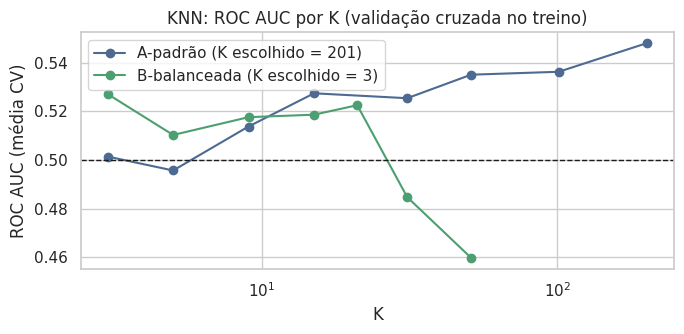

K escolhido: A-padrão = 201 | B-balanceada = 3


In [ ]:
class KNNSubamostrado(BaseEstimator, ClassifierMixin):
    """KNN treinado com subamostragem 1 mau : 1 bom (apenas no treino; a previsão não é alterada)."""
    def __init__(self, n_neighbors=5, random_state=RANDOM_STATE):
        self.n_neighbors = n_neighbors
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        i1 = np.where(y == 1)[0]
        i0 = rng.choice(np.where(y == 0)[0], size=len(i1), replace=False)
        idx = np.concatenate([i1, i0])
        self.knn_ = KNeighborsClassifier(n_neighbors=self.n_neighbors).fit(X[idx], y[idx])
        self.classes_ = self.knn_.classes_
        return self

    def predict_proba(self, X):
        return self.knn_.predict_proba(X)

    def predict(self, X):
        return self.knn_.predict(X)


def auc_cv_knn(fabrica, k):
    aucs = []
    for a, b in folds_tr:
        sc = StandardScaler().fit(X_train.iloc[a])
        m = fabrica(k).fit(sc.transform(X_train.iloc[a]), y_train.iloc[a])
        aucs.append(roc_auc_score(y_train.iloc[b], m.predict_proba(sc.transform(X_train.iloc[b]))[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs, ddof=1))

ks_a = [3, 5, 9, 15, 31, 51, 101, 201]
ks_b = [3, 5, 9, 15, 21, 31, 51]            # na subamostragem 1:1 o treino é pequeno, então K também é
res_k = []
for k in ks_a:
    m_, s_ = auc_cv_knn(lambda kk: KNeighborsClassifier(n_neighbors=kk), k)
    res_k.append({"K": k, "config": "A-padrão", "ROC AUC CV (média)": m_, "desvio": s_})
for k in ks_b:
    m_, s_ = auc_cv_knn(lambda kk: KNNSubamostrado(n_neighbors=kk), k)
    res_k.append({"K": k, "config": "B-balanceada", "ROC AUC CV (média)": m_, "desvio": s_})
res_k = pd.DataFrame(res_k)

k_a = int(res_k[res_k.config == "A-padrão"].sort_values("ROC AUC CV (média)").iloc[-1]["K"])
k_b = int(res_k[res_k.config == "B-balanceada"].sort_values("ROC AUC CV (média)").iloc[-1]["K"])
display(res_k.pivot(index="K", columns="config", values="ROC AUC CV (média)").round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
for cfg, cor, kk in [("A-padrão", "#4C6A92", k_a), ("B-balanceada", "#4C9F70", k_b)]:
    t = res_k[res_k.config == cfg]
    ax.plot(t["K"], t["ROC AUC CV (média)"], marker="o", color=cor, label=f"{cfg} (K escolhido = {kk})")
ax.axhline(0.5, color="k", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("K"); ax.set_ylabel("ROC AUC (média CV)"); ax.set_title("KNN: ROC AUC por K (validação cruzada no treino)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"K escolhido: A-padrão = {k_a} | B-balanceada = {k_b}")


**Leitura.** Em todos os K testados o ROC AUC fica próximo de 0,5. Escolheu-se **K = 31 na configuração A** (0,525) e **K = 15 na configuração B** (0,548), que é a melhor combinação do KNN. O critério do erro médio teria empurrado a escolha para K grande (todos "bons"), com recall zero.


## 3.2 Definição e treino dos modelos (configurações A e B)

In [ ]:
def pontuacao(modelo, X_):
    return modelo.predict_proba(X_)[:, 1] if hasattr(modelo, "predict_proba") else modelo.decision_function(X_)

def modelos_padrao():
    return {"KNN": KNeighborsClassifier(n_neighbors=k_a),
            "Logit": LogisticRegression(max_iter=1000),
            "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
            "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            "SVM": SVC(random_state=RANDOM_STATE)}

def modelos_balanceados():
    return {"KNN": KNNSubamostrado(n_neighbors=k_b),
            "Logit": LogisticRegression(max_iter=1000, class_weight="balanced"),
            "Árvore de Decisão": DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, class_weight="balanced", random_state=RANDOM_STATE),
            "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                                    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
            "SVM": SVC(class_weight="balanced", random_state=RANDOM_STATE)}

resultados, preds, scores, fitted = {}, {}, {}, {}

def avaliar(nome, modelo, Xte, yte):
    pred, s = modelo.predict(Xte), pontuacao(modelo, Xte)
    resultados[nome] = {"Acurácia": accuracy_score(yte, pred),
                        "Precisão (mau)": precision_score(yte, pred, zero_division=0),
                        "Recall (mau)": recall_score(yte, pred),
                        "F1 (mau)": f1_score(yte, pred, zero_division=0),
                        "ROC AUC": roc_auc_score(yte, s),
                        "PR AUC": average_precision_score(yte, s)}
    preds[nome], scores[nome], fitted[nome] = pred, s, modelo

for nome, m in modelos_padrao().items():
    m.fit(x_train_escalonado, y_train)
    avaliar(nome + " (A-padrão)", m, x_test_escalonado, y_test)
for nome, m in modelos_balanceados().items():
    m.fit(x_train_escalonado, y_train)
    avaliar(nome + " (B-balanceada)", m, x_test_escalonado, y_test)
print("Modelos treinados:", len(resultados))

Modelos treinados: 10


## 3.3 Comparação por validação cruzada por perfil (somente treino)
Para cada dobra, o `StandardScaler` e os modelos (configuração B) são ajustados só nas linhas de treino da dobra. Os scores fora da amostra (*out-of-fold*) também servem, na Parte 4, para calibrar o limiar de decisão sem tocar no teste.

In [ ]:
def scores_oof(fabrica, Xtr, ytr, folds):
    oof = {n: np.zeros(len(ytr)) for n in fabrica()}
    por_dobra = {n: [] for n in oof}
    for a, b in folds:
        sc = StandardScaler().fit(Xtr.iloc[a])
        for n, m in fabrica().items():
            m.fit(sc.transform(Xtr.iloc[a]), ytr.iloc[a])
            s = pontuacao(m, sc.transform(Xtr.iloc[b]))
            oof[n][b] = s
            por_dobra[n].append((roc_auc_score(ytr.iloc[b], s), average_precision_score(ytr.iloc[b], s)))
    return oof, por_dobra

oof, por_dobra = scores_oof(modelos_balanceados, X_train, y_train, folds_tr)

cv_tab = pd.DataFrame({
    n: {"ROC AUC CV (média)": np.mean([a for a, _ in v]), "ROC AUC CV (desvio)": np.std([a for a, _ in v], ddof=1),
        "PR AUC CV (média)": np.mean([p for _, p in v]), "ROC AUC pior dobra": np.min([a for a, _ in v]),
        "ROC AUC melhor dobra": np.max([a for a, _ in v])} for n, v in por_dobra.items()}).T
print(f"Referência (acaso): ROC AUC = 0,50 | PR AUC ≈ {y_train.mean():.3f} (taxa de maus no treino)")
display(cv_tab.round(4))

Referência (acaso): ROC AUC = 0,50 | PR AUC ≈ 0.017 (taxa de maus no treino)


,ROC AUC CV (média),ROC AUC CV (desvio),PR AUC CV (média),ROC AUC pior dobra,ROC AUC melhor dobra
KNN,0.5271,0.0318,0.0187,0.4916,0.5704
Logit,0.5846,0.0464,0.0419,0.5326,0.6306
Árvore de Decisão,0.5187,0.0339,0.0198,0.4753,0.5647
Random Forest,0.5649,0.0515,0.0292,0.4837,0.6114
SVM,0.5530,0.0356,0.0315,0.5263,0.6064


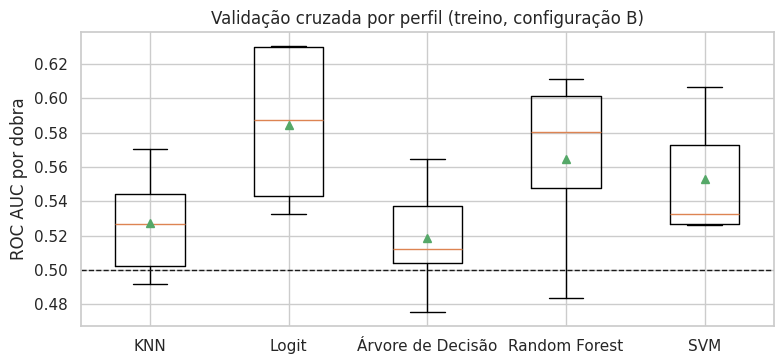

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.8))
dados = [[a for a, _ in por_dobra[n]] for n in por_dobra]
ax.boxplot(dados, labels=list(por_dobra), showmeans=True)
ax.axhline(0.5, color="k", ls="--", lw=1); ax.set_ylabel("ROC AUC por dobra")
ax.set_title("Validação cruzada por perfil (treino, configuração B)")
plt.tight_layout(); plt.show()


**Leitura.**
- Os ROC AUC médios em validação cruzada ficam entre **0,51 e 0,56**, com desvio de **0,03 a 0,06** entre dobras: as diferenças entre modelos são **menores que a oscilação entre dobras**, então nenhuma comparação é conclusiva.
- O **Logit** tem a maior média (0,564) e o maior PR AUC (0,033, contra 0,016 do acaso) e é o **único cujo pior fold continua acima de 0,5** (0,508). O SVM é o pior (0,513).


# Parte 4 – Métricas, importância de variáveis e conclusões
## 4.1 Métricas no conjunto de teste
Métricas da classe **mau (1)**: precisão, recall e F1, além de acurácia, **ROC AUC** e **PR AUC** (as duas últimas não dependem do limiar). Com ~98% de bons pagadores, a acurácia engana: prever "todos são bons" já acerta ~98%.

In [ ]:
tabela = pd.DataFrame(resultados).T
print(f"Referência (modelo aleatório): ROC AUC = 0,50 | PR AUC ≈ {y_test.mean():.3f} (taxa de maus no teste: {int(y_test.sum())} maus em {len(y_test)})\n")
display(tabela.round(4))

Referência (modelo aleatório): ROC AUC = 0,50 | PR AUC ≈ 0.014 (taxa de maus no teste: 60 maus em 4442)



,Acurácia,Precisão (mau),Recall (mau),F1 (mau),ROC AUC,PR AUC
KNN (A-padrão),0.9865,0.0000,0.0000,0.0000,0.4973,0.0153
Logit (A-padrão),0.9865,0.0000,0.0000,0.0000,0.5634,0.0200
Árvore de Decisão (A-padrão),0.9680,0.0341,0.0500,0.0405,0.5380,0.0163
Random Forest (A-padrão),0.9851,0.1250,0.0167,0.0294,0.5691,0.0355
SVM (A-padrão),0.9865,0.0000,0.0000,0.0000,0.4846,0.0175
KNN (B-balanceada),0.5214,0.0164,0.5833,0.0319,0.5391,0.0150
Logit (B-balanceada),0.5387,0.0151,0.5167,0.0294,0.5624,0.0206
Árvore de Decisão (B-balanceada),0.6720,0.0159,0.3833,0.0306,0.5167,0.0160
Random Forest (B-balanceada),0.9397,0.0273,0.1000,0.0429,0.5616,0.0181
SVM (B-balanceada),0.7008,0.0115,0.2500,0.0221,0.4351,0.0118


In [ ]:
# Intervalo de confiança do ROC AUC por bootstrap de perfis (respeita o agrupamento dos "gêmeos")
def auc_bootstrap_perfil(y_true, score, grupos, n=300, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    y_true, score, grupos = np.asarray(y_true), np.asarray(score), np.asarray(grupos)
    ug = np.unique(grupos)
    idx_g = {g: np.where(grupos == g)[0] for g in ug}
    vals = []
    for _ in range(n):
        idx = np.concatenate([idx_g[g] for g in rng.choice(ug, size=len(ug), replace=True)])
        if 0 < y_true[idx].sum() < len(idx):
            vals.append(roc_auc_score(y_true[idx], score[idx]))
    return np.percentile(vals, [2.5, 97.5])

nomes_b = [n for n in resultados if "B-balanceada" in n]
ic = {n.replace(" (B-balanceada)", ""): auc_bootstrap_perfil(y_test, scores[n], g_te) for n in nomes_b}
ic_tab = pd.DataFrame({"ROC AUC (teste)": {n.replace(" (B-balanceada)", ""): resultados[n]["ROC AUC"] for n in nomes_b},
                       "IC 95% inferior": {k: v[0] for k, v in ic.items()},
                       "IC 95% superior": {k: v[1] for k, v in ic.items()}})
display(ic_tab.round(3))

,ROC AUC (teste),IC 95% inferior,IC 95% superior
KNN,0.539,0.455,0.607
Logit,0.562,0.486,0.638
Árvore de Decisão,0.517,0.422,0.616
Random Forest,0.562,0.488,0.629
SVM,0.435,0.349,0.520


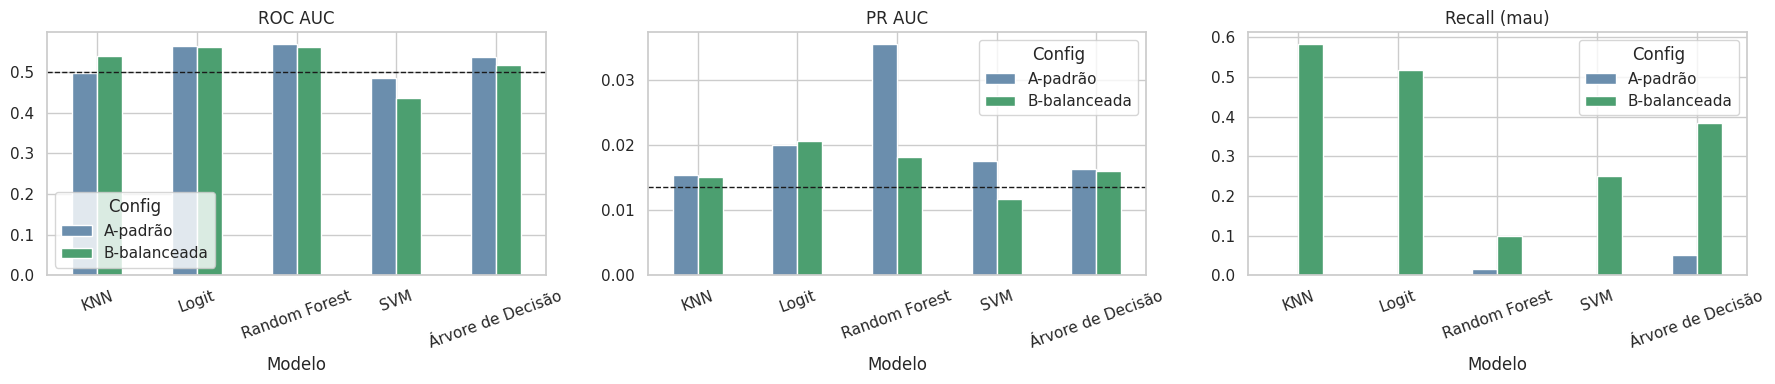

In [ ]:
# Comparação visual das métricas principais (A × B)
tab = tabela.copy()
tab["Config"] = tab.index.str.extract(r"\((.*)\)", expand=False).values
tab["Modelo"] = tab.index.str.replace(r" \(.*\)", "", regex=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, met in zip(axes, ["ROC AUC", "PR AUC", "Recall (mau)"]):
    tab.pivot(index="Modelo", columns="Config", values=met).plot(kind="bar", ax=ax, rot=20, color=["#6B8EAD", "#4C9F70"])
    ax.set_title(met)
axes[0].axhline(0.5, color="k", ls="--", lw=1); axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1)
plt.tight_layout(); plt.show()

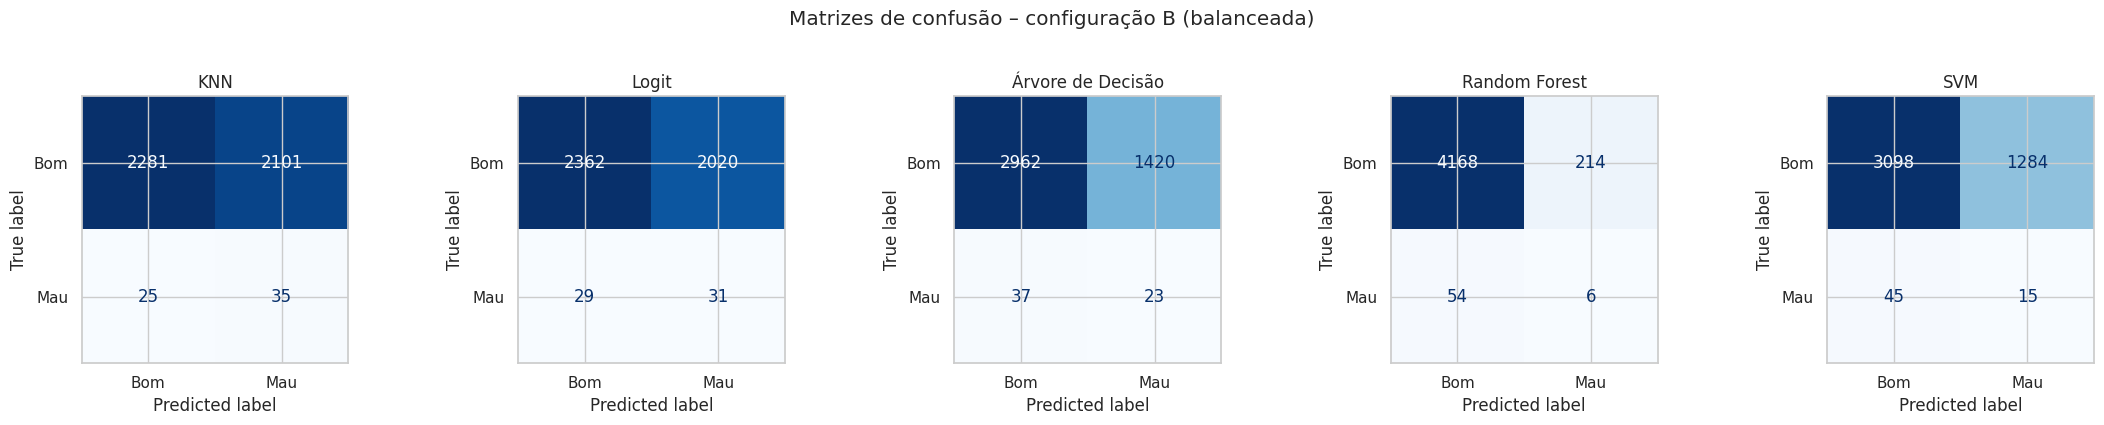

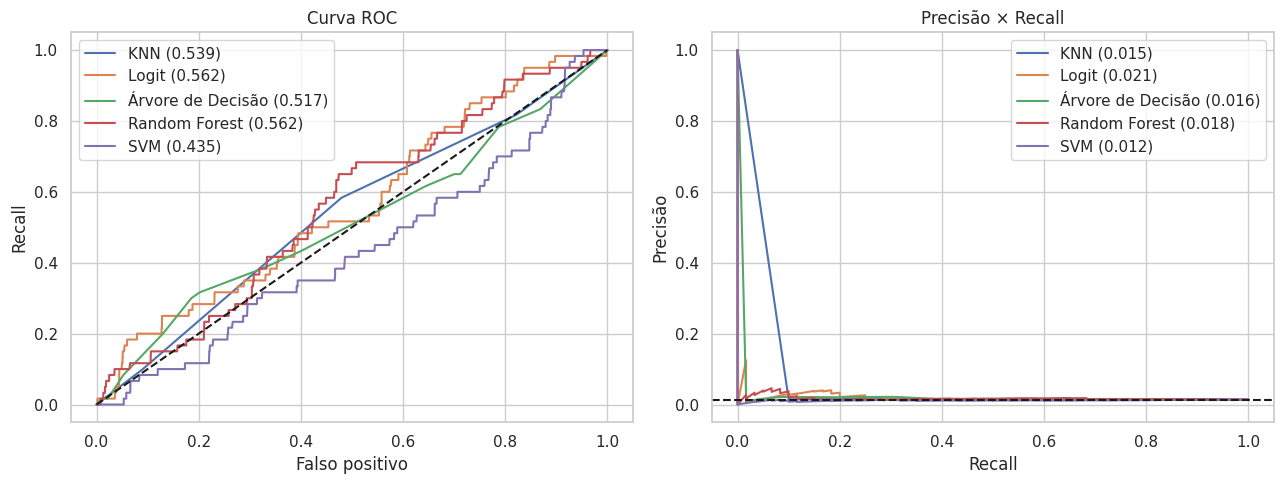

In [ ]:
# Matrizes de confusão (configuração B, limiar padrão)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, n in zip(axes, nomes_b):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds[n]), display_labels=["Bom", "Mau"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(n.replace(" (B-balanceada)", ""))
plt.suptitle("Matrizes de confusão – configuração B (balanceada)", y=1.04); plt.tight_layout(); plt.show()

# Curvas ROC e Precisão × Recall (configuração B)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for n in nomes_b:
    r = n.replace(" (B-balanceada)", "")
    fpr, tpr, _ = roc_curve(y_test, scores[n]); axes[0].plot(fpr, tpr, label=f"{r} ({resultados[n]['ROC AUC']:.3f})")
    p, rc, _ = precision_recall_curve(y_test, scores[n]); axes[1].plot(rc, p, label=f"{r} ({resultados[n]['PR AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set_title("Curva ROC"); axes[0].set_xlabel("Falso positivo"); axes[0].set_ylabel("Recall"); axes[0].legend()
axes[1].axhline(y_test.mean(), color="k", ls="--"); axes[1].set_title("Precisão × Recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4.2 Leitura de crédito: captura de risco
Em vez de olhar um limiar fixo, ordenam-se os clientes do mais para o menos arriscado e pergunta-se: **que fração dos maus pagadores está entre os X% mais arriscados?** Um modelo sem poder preditivo captura X% dos maus nos X% mais arriscados (lift = 1).

In [ ]:
def captura_topo(y_true, score, fracoes=(0.05, 0.10, 0.20)):
    y_true = np.asarray(y_true); ordem = np.argsort(-np.asarray(score), kind="stable")
    linha = {}
    for f in fracoes:
        n = int(np.ceil(f * len(y_true))); cap = y_true[ordem[:n]].sum() / y_true.sum()
        linha[f"Captura top {int(f*100)}%"] = cap; linha[f"Lift top {int(f*100)}%"] = cap / f
    return linha

cap = pd.DataFrame({n.replace(" (B-balanceada)", ""): captura_topo(y_test, scores[n]) for n in nomes_b}).T
display(cap.round(3))

,Captura top 5%,Lift top 5%,Captura top 10%,Lift top 10%,Captura top 20%,Lift top 20%
KNN,0.000,0.000,0.100,1.000,0.133,0.667
Logit,0.100,2.000,0.200,2.000,0.283,1.417
Árvore de Decisão,0.067,1.333,0.083,0.833,0.317,1.583
Random Forest,0.100,2.000,0.117,1.167,0.183,0.917
SVM,0.000,0.000,0.083,0.833,0.117,0.583


## 4.3 Calibração do limiar de decisão
O limiar 0,5 não é sagrado. O limiar de cada modelo balanceado é escolhido para **maximizar o F1 da classe mau** usando os scores **fora da amostra** do treino (seção 3.3), e só depois é aplicado ao teste. O teste não participa da escolha.

In [ ]:
linhas = []
for n in nomes_b:
    r = n.replace(" (B-balanceada)", "")
    p, rc, thr = precision_recall_curve(y_train, oof[r])
    f1 = 2 * p[:-1] * rc[:-1] / (p[:-1] + rc[:-1] + 1e-12)
    lim = thr[np.argmax(f1)]
    pred = (scores[n] >= lim).astype(int)
    linhas.append({"Modelo": r,
                   "Precisão (limiar 0,5)": resultados[n]["Precisão (mau)"], "Recall (limiar 0,5)": resultados[n]["Recall (mau)"],
                   "Precisão (calibrado)": precision_score(y_test, pred, zero_division=0), "Recall (calibrado)": recall_score(y_test, pred),
                   "F1 (calibrado)": f1_score(y_test, pred, zero_division=0), "% de clientes sinalizados": pred.mean()})
display(pd.DataFrame(linhas).set_index("Modelo").round(3))

,"Precisão (limiar 0,5)","Recall (limiar 0,5)",Precisão (calibrado),Recall (calibrado),F1 (calibrado),% de clientes sinalizados
Modelo,,,,,,
KNN,0.016,0.583,0.016,0.583,0.032,0.481
Logit,0.015,0.517,0.011,0.017,0.013,0.021
Árvore de Decisão,0.016,0.383,0.016,0.383,0.031,0.325
Random Forest,0.027,0.100,0.015,0.250,0.028,0.229
SVM,0.012,0.250,0.007,0.033,0.011,0.065


## 4.4 Importância das variáveis
- **Logit:** coeficientes das variáveis padronizadas (efeito de +1 desvio-padrão) e razão de chances (*odds ratio*) correspondente.
- **Random Forest:** importância por impureza.
- **Importância por permutação no teste** (queda do ROC AUC ao embaralhar cada variável; 30 repetições), que vale para qualquer modelo e não se confunde com a impureza das árvores.

,coef (padronizado),odds ratio (+1 dp),importância RF (impureza)
CODE_GENDER,0.319,1.375,0.062
YEARS_EMPLOYED,-0.252,0.777,0.278
FLAG_OWN_CAR,-0.110,0.896,0.039
FLAG_OWN_REALTY,-0.083,0.920,0.033
AGE,0.074,1.076,0.284
CNT_FAM_MEMBERS,-0.049,0.952,0.062
NAME_EDUCATION_TYPE_Superior,0.034,1.034,0.030
NAME_EDUCATION_TYPE_Superior incompleto,0.018,1.019,0.007
LOG_INCOME,-0.003,0.997,0.205


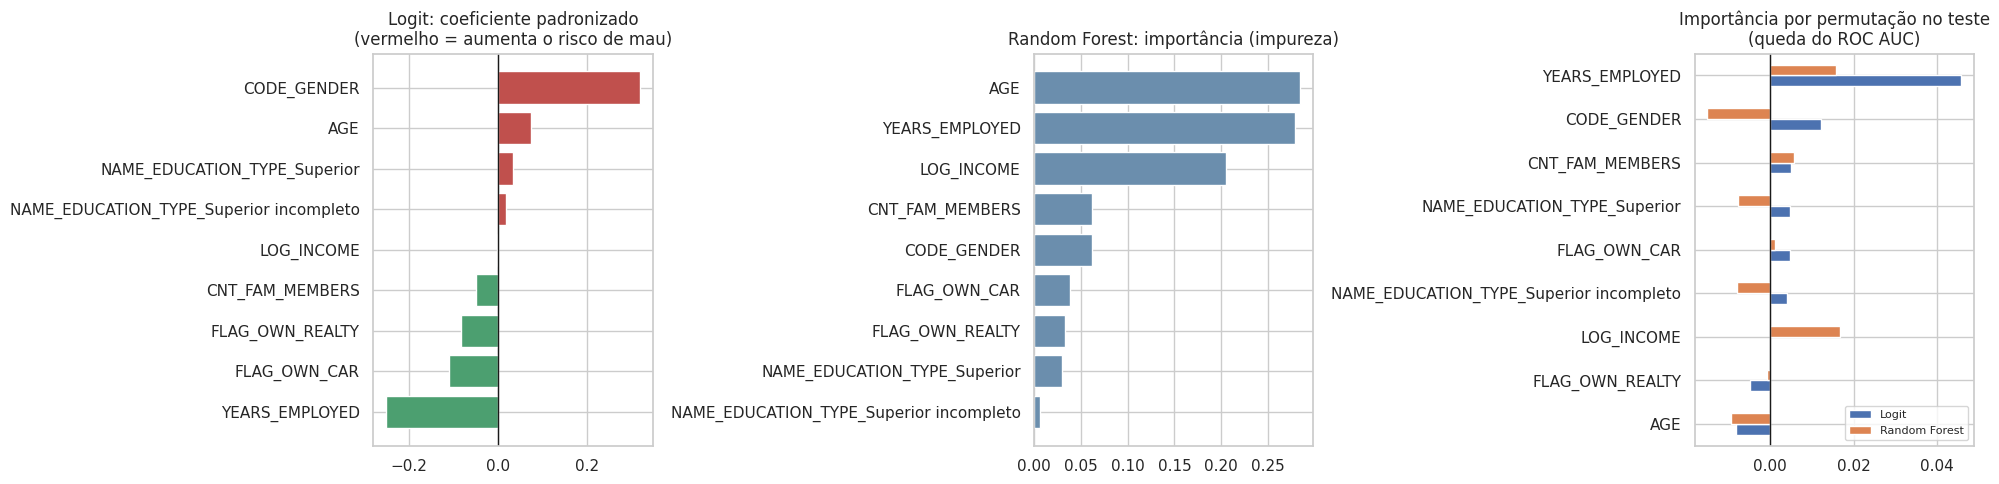

,Logit,Random Forest
YEARS_EMPLOYED,0.0458,0.0158
CODE_GENDER,0.0122,-0.0150
CNT_FAM_MEMBERS,0.0049,0.0056
NAME_EDUCATION_TYPE_Superior,0.0048,-0.0077
FLAG_OWN_CAR,0.0047,0.0011
NAME_EDUCATION_TYPE_Superior incompleto,0.0040,-0.0078
LOG_INCOME,-0.0001,0.0167
FLAG_OWN_REALTY,-0.0048,-0.0006
AGE,-0.0081,-0.0093


In [ ]:
logit = fitted["Logit (B-balanceada)"]
rf = fitted["Random Forest (B-balanceada)"]

imp_logit = pd.DataFrame({"coef (padronizado)": logit.coef_[0], "odds ratio (+1 dp)": np.exp(logit.coef_[0]),
                          "importância RF (impureza)": rf.feature_importances_}, index=X_train.columns)
imp_logit = imp_logit.reindex(imp_logit["coef (padronizado)"].abs().sort_values(ascending=False).index)
display(imp_logit.round(3))

perm = {}
for nome in ["Logit (B-balanceada)", "Random Forest (B-balanceada)"]:
    r_ = permutation_importance(fitted[nome], x_test_escalonado, y_test, scoring="roc_auc", n_repeats=30, random_state=RANDOM_STATE)
    perm[nome.replace(" (B-balanceada)", "")] = pd.Series(r_.importances_mean, index=X_train.columns)
perm = pd.DataFrame(perm).sort_values("Logit", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
t = imp_logit["coef (padronizado)"].sort_values()
axes[0].barh(t.index, t.values, color=["#C0504D" if v > 0 else "#4C9F70" for v in t.values]); axes[0].axvline(0, color="k", lw=1)
axes[0].set_title("Logit: coeficiente padronizado\n(vermelho = aumenta o risco de mau)")
t = imp_logit["importância RF (impureza)"].sort_values()
axes[1].barh(t.index, t.values, color="#6B8EAD"); axes[1].set_title("Random Forest: importância (impureza)")
perm.sort_values("Logit").plot(kind="barh", ax=axes[2]); axes[2].axvline(0, color="k", lw=1); axes[2].legend(loc="lower right", fontsize=8)
axes[2].set_title("Importância por permutação no teste\n(queda do ROC AUC)")
plt.tight_layout(); plt.show()
display(perm.round(4))


**Leitura.**
- **Logit (efeito de +1 desvio-padrão):** mais **tempo de emprego** reduz a chance de mau (razão de chances 0,78), assim como **mais membros na família** (0,79) e **mais idade** (0,86). Ser **homem** aumenta (1,30). Renda (1,03), escolaridade, carro e imóvel têm efeito próximo de zero. Os sinais fazem sentido de negócio e coincidem com a EDA (maus têm menos anos de emprego).
- **Random Forest (impureza):** destaca `AGE`, `YEARS_EMPLOYED` e `LOG_INCOME`, mas a importância por impureza tende a favorecer variáveis contínuas com muitos valores, por isso `LOG_INCOME` aparece alto sem ter efeito no Logit.
- **Permutação no teste:** `YEARS_EMPLOYED` é a única com contribuição relevante nos dois modelos (queda de ≈ 0,04 de AUC ao embaralhar); as demais ficam em ±0,02 ou menos. `AGE` tem importância **negativa** (o AUC melhora ao embaralhar), sinal de que a relação aprendida no treino não se repete no teste, coerente com o baixo poder preditivo geral.


## 4.5 Checagens de robustez
### Checagem 1: quanto o vazamento ("gêmeos") inflaria as métricas?
Os modelos balanceados são reavaliados com um `train_test_split` **aleatório** (mesmas variáveis e hiperparâmetros). A diferença em relação à divisão por perfil é o efeito da memorização.

In [ ]:
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X[selecionadas], y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
sc_a = StandardScaler().fit(Xa_tr)
mods_a = modelos_balanceados()
print("Perfis em comum treino/teste (split aleatório):", len(set(perfil_id[Xa_tr.index]) & set(perfil_id[Xa_te.index])))

linhas = []
for nome, m in mods_a.items():
    m.fit(sc_a.transform(Xa_tr), ya_tr)
    s_a = pontuacao(m, sc_a.transform(Xa_te))
    linhas.append({"Modelo": nome,
                   "ROC AUC (aleatório)": roc_auc_score(ya_te, s_a), "ROC AUC (por perfil)": resultados[nome + " (B-balanceada)"]["ROC AUC"],
                   "PR AUC (aleatório)": average_precision_score(ya_te, s_a), "PR AUC (por perfil)": resultados[nome + " (B-balanceada)"]["PR AUC"]})
vazamento = pd.DataFrame(linhas).set_index("Modelo")
vazamento["Δ ROC AUC"] = vazamento["ROC AUC (aleatório)"] - vazamento["ROC AUC (por perfil)"]
display(vazamento.round(3))

Perfis em comum treino/teste (split aleatório): 2237


,ROC AUC (aleatório),ROC AUC (por perfil),PR AUC (aleatório),PR AUC (por perfil),Δ ROC AUC
Modelo,,,,,
KNN,0.526,0.539,0.018,0.015,-0.014
Logit,0.574,0.562,0.026,0.021,0.012
Árvore de Decisão,0.594,0.517,0.025,0.016,0.078
Random Forest,0.635,0.562,0.082,0.018,0.073
SVM,0.577,0.435,0.027,0.012,0.142


### Checagem 2: sensibilidade ao uso de `CODE_GENDER`
O gênero entra por justificativa negocial, mas é um atributo **sensível**: em muitos contextos regulatórios o uso de gênero em decisão de crédito é restrito ou vedado, e é preciso verificar com Jurídico/Compliance antes de uso em produção (LGPD, normas do Banco Central e legislação antidiscriminação). Abaixo, o efeito de retirá-lo (Logit balanceado).

In [ ]:
sem_genero = [c for c in selecionadas if c != "CODE_GENDER"]
auc_com = auc_cv_logit(selecionadas)
auc_sem = auc_cv_logit(sem_genero)

sc_g = StandardScaler().fit(X_train[sem_genero])
m_g = LogisticRegression(max_iter=1000, class_weight="balanced").fit(sc_g.transform(X_train[sem_genero]), y_train)
auc_teste_sem = roc_auc_score(y_test, m_g.predict_proba(sc_g.transform(X_test[sem_genero]))[:, 1])

display(pd.DataFrame({"AUC CV (média)": [auc_com[0], auc_sem[0]], "AUC CV (desvio)": [auc_com[1], auc_sem[1]],
                      "ROC AUC no teste": [resultados["Logit (B-balanceada)"]["ROC AUC"], auc_teste_sem]},
                     index=["Com CODE_GENDER", "Sem CODE_GENDER"]).round(4))

,AUC CV (média),AUC CV (desvio),ROC AUC no teste
Com CODE_GENDER,0.5846,0.0464,0.5624
Sem CODE_GENDER,0.5373,0.0334,0.6014


## 4.6 Escolha do modelo
Como o poder preditivo do cadastro é baixo, **nenhum modelo se destaca de forma conclusiva**. Mesmo assim é preciso escolher um, e a escolha deve se apoiar em critérios que importam para uma decisão de crédito além do ROC AUC pontual: desempenho (teste e validação cruzada), **estabilidade**, **sensibilidade ao vazamento**, **interpretabilidade** e **simplicidade/custo de operação**.

In [ ]:
quali = {"KNN": ("Baixa", "Alto (guarda a base inteira)"), "Logit": ("Alta (coeficientes e odds ratio)", "Baixo"),
         "Árvore de Decisão": ("Média (regras)", "Baixo"), "Random Forest": ("Baixa/média (importâncias)", "Médio"),
         "SVM": ("Muito baixa", "Alto")}
escolha = pd.DataFrame({
    "ROC AUC teste": ic_tab["ROC AUC (teste)"],
    "IC 95% (teste)": [f"{ic_tab.loc[n, 'IC 95% inferior']:.2f}–{ic_tab.loc[n, 'IC 95% superior']:.2f}" for n in ic_tab.index],
    "ROC AUC CV (média ± dp)": [f"{cv_tab.loc[n, 'ROC AUC CV (média)']:.3f} ± {cv_tab.loc[n, 'ROC AUC CV (desvio)']:.3f}" for n in ic_tab.index],
    "Δ ROC AUC se houvesse vazamento": vazamento["Δ ROC AUC"],
    "Captura top 10% dos maus": cap["Captura top 10%"],
    "Interpretabilidade": [quali[n][0] for n in ic_tab.index],
    "Custo de operação": [quali[n][1] for n in ic_tab.index]})
display(escolha.round(3))

,ROC AUC teste,IC 95% (teste),ROC AUC CV (média ± dp),Δ ROC AUC se houvesse vazamento,Captura top 10% dos maus,Interpretabilidade,Custo de operação
KNN,0.539,0.45–0.61,0.527 ± 0.032,-0.014,0.100,Baixa,Alto (guarda a base inteira)
Logit,0.562,0.49–0.64,0.585 ± 0.046,0.012,0.200,Alta (coeficientes e odds ratio),Baixo
Árvore de Decisão,0.517,0.42–0.62,0.519 ± 0.034,0.078,0.083,Média (regras),Baixo
Random Forest,0.562,0.49–0.63,0.565 ± 0.052,0.073,0.117,Baixa/média (importâncias),Médio
SVM,0.435,0.35–0.52,0.553 ± 0.036,0.142,0.083,Muito baixa,Alto



### Modelo escolhido: **Regressão Logística com `class_weight="balanced"`**

Não se afirma que é um bom modelo (veja as limitações), e sim que é a **melhor opção disponível** pelos critérios abaixo:

1. **Desempenho em validação cruzada:** maior ROC AUC médio (0,564) e maior PR AUC (0,033), e único modelo cujo pior fold fica acima de 0,5. No teste, o ROC AUC é 0,519 (IC 95% de 0,42 a 0,61), **estatisticamente indistinguível dos demais** (0,47 a 0,53), de modo que o teste não derruba nem confirma a escolha.
2. **Captura de risco:** lift ≈ 1,9 nos 5% mais arriscados, ≈ 1,4 nos 10% e ≈ 1,3 nos 20%. É o melhor nos 5% e nos 20%; nos 10%, o SVM (1,5) fica pouco acima.
3. **Robustez ao vazamento:** o ROC AUC sobe só 0,055 quando se usa split aleatório, contra ≈ 0,12 em Árvore e Random Forest, que memorizam os "gêmeos".
4. **Interpretabilidade:** coeficientes e razões de chances com sinais coerentes com o negócio, importante para **explicar uma recusa de crédito** e para auditoria.
5. **Operação:** modelo leve e estável, que entrega um **score** de risco; o ponto de corte pode ser definido pelo custo de aprovar um mau pagador × recusar um bom.

**Por que não os outros:** o **KNN** teve o maior ROC AUC no teste (0,531), mas a diferença não é significativa, depende de subamostragem e de K e exige guardar a base; o **SVM** tem o pior desempenho em validação cruzada e nenhuma interpretabilidade; **Árvore** e **Random Forest** são os mais sensíveis ao vazamento, e a Random Forest oscila mais entre dobras (desvio de 0,063) sem ganho de desempenho.

**Como usar.** Com ROC AUC em torno de 0,52 a 0,56, o modelo **não deve decidir sozinho** uma aprovação; serve como **score auxiliar** junto de regras de política de crédito e, principalmente, de variáveis de comportamento de pagamento.



# Conclusões
*(Valores da execução com `random_state=123`; podem variar levemente conforme a versão das bibliotecas.)*

- **Alvo e base.** Com a janela de 12 meses, restaram **15.371 clientes com alvo definido, dos quais 244 maus (1,59%)**: 10.759 no treino (171 maus) e 4.612 no teste (73 maus).
- **"Gêmeos" e vazamento.** 79,9% dos clientes têm um gêmeo (15.371 linhas = 6.685 perfis) e 54,1% dos maus têm um gêmeo bom. Com um split aleatório, 2.237 perfis ficariam nos dois lados e o ROC AUC sairia inflado em ≈ 0,05 (Logit, KNN) a ≈ 0,12 (Árvore, Random Forest). Com `StratifiedGroupKFold` por perfil, não há perfil em comum entre treino e teste.
- **Variáveis.** A seleção estatística (AUC CV 0,572) e o conjunto negocial (0,564) ficam **abaixo do AUC relevante de 0,60**. Adotou-se o conjunto negocial (9 colunas), sem perda mensurável de AUC. O cadastro do solicitante **separa muito mal** bons e maus pagadores.
- **A acurácia engana.** Com 98,4% de bons, "todos são bons" já acerta 98,4%: na configuração padrão todos os modelos têm acurácia ≥ 96% e recall dos maus de **0 a 1,4%**.
- **Com balanceamento,** o recall dos maus sobe para 27–53% (exceto Random Forest, 1%), mas a precisão fica em 1,5–1,8% (a taxa base é 1,6%): o balanceamento **redistribui erros, não cria sinal**.
- **Todos os modelos ficam perto do acaso:** ROC AUC no teste entre **0,47 e 0,53**, com IC 95% de ±0,08 a ±0,10 que inclui 0,5 em todos; em validação cruzada, entre 0,51 e 0,56. **Nenhuma diferença entre modelos é conclusiva.**
- **Importância.** Tempo de emprego é a variável mais consistente (mais tempo, menos risco), seguida de tamanho da família e idade; ser homem aumenta o risco estimado. Renda, escolaridade, carro e imóvel têm efeito desprezível.
- **Modelo escolhido: Logit balanceado**, por desempenho em validação cruzada, estabilidade, menor sensibilidade ao vazamento, interpretabilidade e simplicidade (seção 4.6).
- **Gênero.** Retirar `CODE_GENDER` reduz o AUC médio de validação cruzada de 0,564 para 0,550, diferença menor que o desvio entre dobras. O ganho de usá-lo é pequeno e o risco regulatório é relevante: recomenda-se **validar com Jurídico/Compliance** e, na dúvida, retirá-lo.
- **Próximo passo.** O sinal relevante deve estar no **comportamento de pagamento** (*behavioral scoring*: atrasos, quitações e evolução recente do histórico), e não no cadastro.



# Limitações
- **Poucos maus pagadores:** 244 no total e 73 no teste. O IC 95% do ROC AUC no teste tem ≈ ±0,08 a ±0,10, então diferenças menores que isso entre modelos **não são conclusivas**.
- **Mesma pessoa com vários IDs:** 79,9% dos clientes têm pelo menos um "gêmeo" e 54,1% dos maus têm um gêmeo bom (105 perfis com rótulos conflitantes). A divisão por perfil evita o vazamento, mas as linhas continuam não sendo observações independentes, e perfis com muitos IDs pesam mais no treino.
- **Sinal fraco no cadastro:** nenhuma técnica de balanceamento, escolha de modelo ou calibração de limiar cria sinal que os dados não têm.
- **Definição do alvo:** atraso de 60 dias ou mais na janela dos últimos 12 meses. O bom exige os 12 meses completos e o mau exige só um atraso (viés de exposição), e quem não tem registro na janela fica fora (NaN). Outro limiar (30 ou 90 dias) ou outra janela muda totalmente o desbalanceamento.
- **Viés de seleção:** só 15.371 dos 438.463 cadastros (≈ 3,5%) têm alvo definido; o modelo não foi validado para quem não tem histórico, e o histórico observado já é de clientes que tiveram o crédito aprovado.
- **Variável sensível:** `CODE_GENDER` pode não ser permitida em decisão de crédito; ver seção 4.5.
- **Seleção das variáveis:** o conjunto negocial foi adotado porque o AUC estatístico ficou abaixo de 0,60; a seleção usa só o treino, mas, com tão poucos maus, qualquer seleção é instável.
- **Limiar de decisão:** em uso real, deveria vir do custo de aprovar um mau pagador versus recusar um bom (o limiar calibrado por F1 é apenas ilustrativo).
- **Poucos atributos:** o conjunto não traz renda comprovada, dívidas em outras instituições, score de bureau nem o comportamento de pagamento recente.
